In [1]:
# Import Libraries
import pandas as pd

# Load the dataset (full path to your large CSV file)
file_path = "/Users/evgeniakouklaki/Library/CloudStorage/OneDrive-Personal/Erasmus | Data Science and Marketing Analytics/Thesis/Revelio Employer Branding/urajgcxbttacmbwv.csv"

#Read file
df = pd.read_csv(file_path)

In [2]:
#Random Sampling
df_sample = df.sample(n=100000, random_state=42)

# Print the final size of your sampled dataset
print(df_sample.shape)

# Show first 5 rows
df_sample.head()

(100000, 38)


,ultimate_parent_rcid,review_date,rcid,company_id,company,review_id,review_language_id,location_raw,country,metro_area,...,rating_work_life_balance,review_summary,review_advice,review_pros,review_cons,review_count_helpful,review_count_not_helpful,onet_code,ultimate_parent_company_name,review_time
2062483,701451.0,27/02/2025,1051469,10090,Pizza Hut LLC,95422278,spa,NaN,NaN,NaN,...,1.0,Anonima,NaN,Agradables compañeros de trabajo\Oportunidad d...,Horarios extendidos mal pago\Explotacion laboral,NaN,NaN,43-4051.00,"Yum! Brands, Inc.",19:51:26
4181214,93604261.0,30/06/2025,93604261,5777767,TRIPEARLTECH PRIVATE LIMITED,98368222,eng,NaN,NaN,NaN,...,5.0,Tripearltech,NaN,Experience at Tripearltech has been truly enri...,No Such Cons as of now.,NaN,NaN,15-1252.00,TRIPEARLTECH PRIVATE LIMITED,06:25:29
1142495,1270580.0,14/02/2025,597311,1289926,Aixial SASU,95027554,fra,Lyon,France,lyon metropolitan area,...,NaN,Évaluation salaire,NaN,Pas assez de recul pour évolution de salaire a...,Pas assez de recul pour évolution de salaire,NaN,NaN,15-1299.09,Alten SA,01:56:47
244807,1260543.0,19/12/2024,128980,3554274,Schoters,93781396,eng,NaN,NaN,NaN,...,NaN,Good place for additional work,NaN,"Flexible, excellent support from Schoters Team",Hours are tied to the students so monthly you ...,NaN,NaN,25-1124.00,PT Ruang Raya Indonesia,04:01:35
2711633,792141.0,28/04/2025,1377965,3140805,BNP Paribas Asset Management Europe SAS,96982761,fra,Paris,France,paris metropolitan area,...,5.0,Salary,NaN,Good salary and good company,No recruiting at the time,NaN,NaN,13-2051.00,BNP Paribas SA,06:46:51


In [3]:
# Check the columns
df_sample.columns

Index(['ultimate_parent_rcid', 'review_date', 'rcid', 'company_id', 'company',
       'review_id', 'review_language_id', 'location_raw', 'country',
       'metro_area', 'state', 'job_title_raw', 'role_k17000', 'seniority',
       'review_iscovid19', 'reviewer_employment_status',
       'reviewer_job_ending_year', 'reviewer_length_of_employment',
       'reviewer_current_job', 'rating_overall', 'rating_business_outlook',
       'rating_career_opportunities', 'rating_ceo',
       'rating_compensation_and_benefits', 'rating_culture_and_values',
       'rating_diversity_and_inclusion', 'rating_recommend_to_friend',
       'rating_senior_leadership', 'rating_work_life_balance',
       'review_summary', 'review_advice', 'review_pros', 'review_cons',
       'review_count_helpful', 'review_count_not_helpful', 'onet_code',
       'ultimate_parent_company_name', 'review_time'],
      dtype='object')

In [4]:
# Filter only english reviews
df_sample = df_sample[df_sample['review_language_id'] == 'eng']
print(df_sample.shape)

(75572, 38)


In [5]:
# Detect language
!pip install langdetect
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

df_sample["detected_lang"] = df_sample["review_summary"].apply(detect_lang)

df_sample["detected_lang"].value_counts()

detected_lang
en         48492
so          3795
af          3046
tl          2380
ro          2249
nl          2084
de          1932
fr          1568
ca          1422
unknown     1005
it           937
es           902
no           733
da           658
id           570
cy           412
pt           383
fi           378
pl           361
sw           338
vi           327
et           289
sl           261
sk           241
hr           187
sv           165
tr           145
lt            85
sq            76
hu            73
cs            37
lv            36
ko             3
zh-cn          1
ru             1
Name: count, dtype: int64

In [6]:
#Keep only rows that detect language is english
_sample = df_sample[df_sample["detected_lang"] == "en"]

In [7]:
# Apply detect language in all the fields
df_sample["lang_summary"] = df_sample["review_summary"].apply(detect_lang)
df_sample["lang_pros"] = df_sample["review_pros"].apply(detect_lang)
df_sample["lang_cons"] = df_sample["review_cons"].apply(detect_lang)

df_sample = df_sample[
    (df_sample["lang_summary"] == "en") &
    (df_sample["lang_pros"] == "en") &
    (df_sample["lang_cons"] == "en")
]
print(len(df_sample))

46026


In [8]:
# Check missining values in the text columns
text_cols = ['review_summary', 'review_pros', 'review_cons', 'review_advice']

df_sample[text_cols].isna().sum()

review_summary        0
review_pros           0
review_cons           0
review_advice     31163
dtype: int64

In [9]:
# Drop rows with missing values in review_summary
df_sample = df_sample.dropna(subset=['review_summary'])
print(df_sample.shape)

(46026, 42)


In [10]:
# Basic Text Cleaning
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\n', ' ', text)  # remove new lines
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply to each text column
df_sample['summary_clean'] = df_sample['review_summary'].apply(clean_text)
df_sample['pros_clean'] = df_sample['review_pros'].apply(clean_text)
df_sample['cons_clean'] = df_sample['review_cons'].apply(clean_text)

# Check 
df_sample[['summary_clean']].head()

,summary_clean
244807,good place for additional work
1371854,a good place to learn contribute and grow in g...
3765871,good org to work with
1741290,very nice employee
1346698,ok work culture


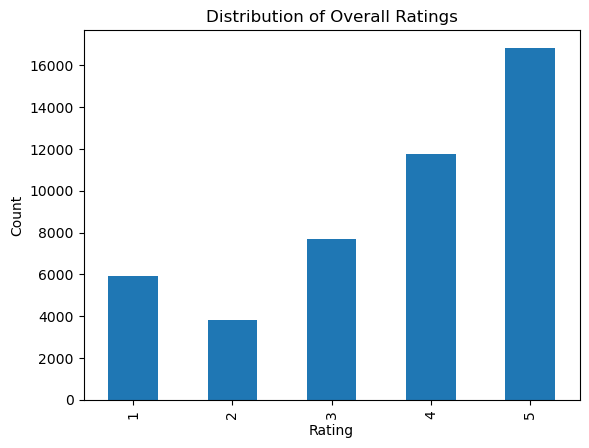

                Count  Percentage (%)
rating_overall                       
1                5918           12.86
2                3807            8.27
3                7714           16.76
4               11751           25.53
5               16836           36.58


In [11]:
# Exploratory Data Analysis:

# Check distribution of ratings
df_sample['rating_overall'].value_counts().sort_index()

# Visual of distribution of ratings 
import matplotlib.pyplot as plt

df_sample['rating_overall'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Overall Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Rating data frame
# Counts
rating_counts = df_sample['rating_overall'].value_counts().sort_index()

# Percentages
rating_percent = df_sample['rating_overall'].value_counts(normalize=True).sort_index() * 100

# Combine
rating_df = pd.DataFrame({
    'Count': rating_counts,
    'Percentage (%)': rating_percent.round(2)
})

print(rating_df)

In [12]:
# Analyze review length
# Create review length columns
df_sample['summary_len'] = df_sample['review_summary'].str.split().str.len()
df_sample['pros_len'] = df_sample['review_pros'].str.split().str.len()
df_sample['cons_len'] = df_sample['review_cons'].str.split().str.len()

# Check descriptive statistics
df_sample[['summary_len', 'pros_len', 'cons_len']].describe()

,summary_len,pros_len,cons_len
count,46026.000000,46026.000000,46026.000000
mean,4.470669,16.784730,24.116630
std,2.682767,24.591665,49.803524
min,1.000000,1.000000,1.000000
25%,2.000000,6.000000,6.000000
50%,4.000000,9.000000,9.000000
75%,6.000000,17.000000,20.000000
max,25.000000,917.000000,1568.000000


In [13]:
# Check duplicates in real data
print("Duplicate summaries in real data:", df_sample.duplicated(subset=['summary_clean']).sum())
print("Duplicate pros in real data:", df_sample.duplicated(subset=['pros_clean']).sum())
print("Duplicate cons in real data:", df_sample.duplicated(subset=['cons_clean']).sum())
print("Total real reviews:", len(df_sample))

Duplicate summaries in real data: 16671
Duplicate pros in real data: 751
Duplicate cons in real data: 1470
Total real reviews: 46026


In [14]:
# Identify the most frequent words in each textual field-real
from collections import Counter
# --- SUMMARY ---
print("TOP WORDS - SUMMARY")
all_words_summary = " ".join(df_sample["summary_clean"].dropna()).split()
print(Counter(all_words_summary).most_common(50))


# --- PROS ---
print("\nTOP WORDS - PROS")
all_words_pros = " ".join(df_sample["pros_clean"].dropna()).split()
print(Counter(all_words_pros).most_common(50))


# --- CONS ---
print("\nTOP WORDS - CONS")
all_words_cons = " ".join(df_sample["cons_clean"].dropna()).split()
print(Counter(all_words_cons).most_common(50))

TOP WORDS - SUMMARY
[('great', 10794), ('to', 9582), ('work', 9541), ('good', 8905), ('company', 7676), ('place', 7236), ('and', 5125), ('a', 4134), ('for', 4013), ('the', 2658), ('with', 2317), ('not', 2197), ('of', 1935), ('but', 1900), ('culture', 1898), ('experience', 1714), ('in', 1547), ('job', 1432), ('is', 1325), ('environment', 1318), ('people', 1313), ('at', 1283), ('it', 1220), ('team', 1217), ('growth', 1165), ('best', 1044), ('you', 1033), ('pay', 926), ('balance', 923), ('career', 853), ('be', 847), ('its', 836), ('working', 835), ('leadership', 822), ('life', 808), ('learning', 805), ('grow', 768), ('management', 758), ('review', 745), ('learn', 715), ('no', 713), ('very', 701), ('nice', 692), ('your', 678), ('supportive', 669), ('workplace', 644), ('start', 616), ('on', 613), ('opportunities', 612), ('bad', 590)]

TOP WORDS - PROS
[('and', 38481), ('to', 24507), ('the', 23465), ('work', 16677), ('a', 15739), ('good', 14219), ('is', 12616), ('of', 12012), ('great', 10980

In [15]:
#BERTopic libraries and model installation
# Install if needed
# !pip install bertopic sentence-transformers umap-learn hdbscan

# Import libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import MaximalMarginalRelevance

In [16]:
# Global Setup BERTopic-
# Sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# UMAP: reduces embedding dimensions
umap_model = UMAP(
    n_neighbors=10,
    n_components=10,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

# HDBSCAN: clusters similar reviews into topics
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# CountVectorizer: extracts words for topic representation
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=1,
    max_df=0.85
)

# MMR: improves topic keywords by reducing redundancy
representation_model = MaximalMarginalRelevance(diversity=0.5)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Silhouette scores: {2: 0.5175072616174741, 3: 0.4040986898895455, 4: 0.3593350857571922, 5: 0.36234362638265205, 6: 0.3487305270161541, 7: 0.3493086822982746}


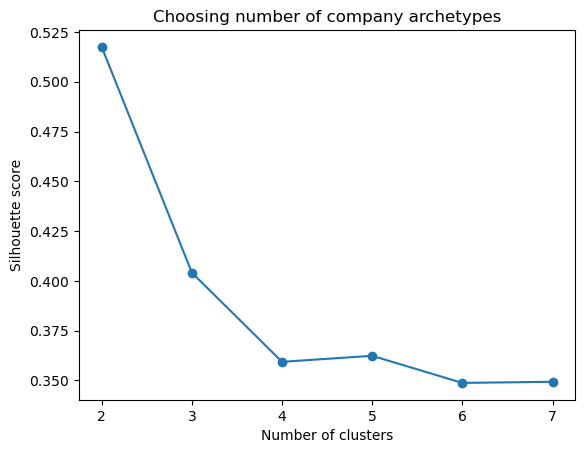


Cluster Profiles:
                  rating_work_life_balance  rating_career_opportunities  \
company_cluster                                                          
0                                    4.74                         4.71   
1                                    1.81                         1.58   
2                                    3.55                         3.38   

                 rating_compensation_and_benefits  rating_senior_leadership  \
company_cluster                                                               
0                                            4.57                      4.76   
1                                            1.85                      1.26   
2                                            3.33                      3.18   

                 rating_culture_and_values  
company_cluster                             
0                                     4.87  
1                                     1.46  
2                                

In [17]:
# Cluster Company Archetypes-real
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# Select rating variables

rating_vars = [
    "rating_work_life_balance",
    "rating_career_opportunities",
    "rating_compensation_and_benefits",
    "rating_senior_leadership",
    "rating_culture_and_values"
]

# Drop missing values
df_cluster = df_sample.dropna(subset=rating_vars).copy()


# Scale data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[rating_vars])

# Find optimal number of clusters

silhouette_scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

print("Silhouette scores:", silhouette_scores)

plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("Choosing number of company archetypes")
plt.show()


# Run final clustering (set k based on the optimal number of clusters, 3)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df_cluster["company_cluster"] = kmeans.fit_predict(X_scaled)


# Analyze clusters

cluster_profiles = df_cluster.groupby("company_cluster")[rating_vars].mean().round(2)
print("\nCluster Profiles:\n", cluster_profiles)

cluster_sizes = df_cluster["company_cluster"].value_counts(normalize=True).round(3)
print("\nCluster Sizes:\n", cluster_sizes)


# Merge back to main dataset

df_sample.loc[df_cluster.index, "company_cluster"] = df_cluster["company_cluster"]


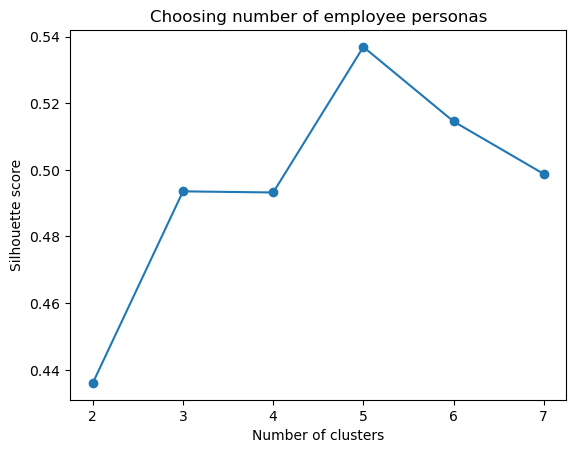


Persona Profiles:

                 seniority  reviewer_length_of_employment  \
persona_cluster                                             
0                 2.421446                       3.056808   
1                 2.995676                      20.000000   
2                 2.108387                       2.738540   

                 reviewer_current_job  
persona_cluster                        
0                             1.00000  
1                             0.68252  
2                             0.00000  

Cluster Sizes:

persona_cluster
0    0.528570
2    0.424731
1    0.046699
Name: proportion, dtype: float64


In [18]:
# Cluster Employee Personas-real
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt


# Select variables

persona_df = df_sample[[
    'seniority',
    'reviewer_length_of_employment',
    'reviewer_current_job'
]].copy()


# Preprocessing


# Convert boolean to int
persona_df['reviewer_current_job'] = persona_df['reviewer_current_job'].astype(int)

# Handle missing values
persona_df = persona_df.dropna()


# Scale features

scaler = StandardScaler()
X = scaler.fit_transform(persona_df)


# Find optimal clusters

sil_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Plot
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Choosing number of employee personas')
plt.show()

# Final clustering
k_optimal = 3  

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
persona_df['persona_cluster'] = kmeans.fit_predict(X)

# Profile personas

persona_profiles = persona_df.groupby('persona_cluster').mean()
print("\nPersona Profiles:\n")
print(persona_profiles)

# Cluster sizes
cluster_sizes = persona_df['persona_cluster'].value_counts(normalize=True)
print("\nCluster Sizes:\n")
print(cluster_sizes)

In [19]:
# Assign meaningfull labels to the company types clusters-real
cluster_name_map = {
    0: "Top Employer Company",
    1: "Challenging Workplace Company",
    2: "Average Workplace Company"
}

df_sample["company_archetype"] = df_sample["company_cluster"].map(cluster_name_map)

In [20]:
 # Check the observations belonging to each company cluster
df_sample["company_archetype"].value_counts()

company_archetype
Top Employer Company             14031
Average Workplace Company        12008
Challenging Workplace Company     8809
Name: count, dtype: int64

In [21]:
# Assign meaningfull labels to the employee types clusters-real
df_sample.loc[persona_df.index, "persona_cluster"] = persona_df["persona_cluster"]
persona_name_map = {
    0: "Active Mid-Level Employee",
    1: "Long-Tenure Veteran",
    2: "Former Employee"
}
df_sample["employee_persona"] = df_sample["persona_cluster"].map(persona_name_map)

In [22]:
# Check the observations belonging to each employee cluster-real
df_sample["employee_persona"].value_counts()

employee_persona
Active Mid-Level Employee    18325
Former Employee              14725
Long-Tenure Veteran           1619
Name: count, dtype: int64

In [23]:
# Check how many observations belong to each combination of company type and employee persona-real
pd.crosstab(
    df_sample["employee_persona"],
    df_sample["company_archetype"])

company_archetype,Average Workplace Company,Challenging Workplace Company,Top Employer Company
employee_persona,,,
Active Mid-Level Employee,5193,2534,8451
Former Employee,4450,4800,3097
Long-Tenure Veteran,532,311,605


In [24]:
# Build matched real sample: 500 (or max available) per persona-archetype combination
def sample_matched(df, group_cols, n=500, random_state=42):
    return (
        df.groupby(group_cols, group_keys=False)
          .apply(lambda g: g.sample(n=min(len(g), n), random_state=random_state))
    )

df_sample_matched = sample_matched(df_sample, ["employee_persona", "company_archetype"], n=500)

# Sanity check: confirm matched sample sizes
pd.crosstab(df_sample_matched["employee_persona"], df_sample_matched["company_archetype"])

company_archetype,Average Workplace Company,Challenging Workplace Company,Top Employer Company
employee_persona,,,
Active Mid-Level Employee,500,500,500
Former Employee,500,500,500
Long-Tenure Veteran,500,311,500


In [126]:
# Descriptive statistics of the equalised real sample (word count)
import pandas as pd

def compute_word_count_stats(df, fields):
    stats = {}
    for field in fields:
        lengths = df[field].dropna().apply(lambda x: len(str(x).split()))
        stats[field] = {
            "mean": round(lengths.mean(), 2),
            "median": round(lengths.median(), 2),
            "std": round(lengths.std(), 2),
            "min": lengths.min(),
            "max": lengths.max(),
        }
    return stats

real_fields = ["summary_clean", "pros_clean", "cons_clean"]
equalised_wc = compute_word_count_stats(df_sample_matched, real_fields)

print("=== DESCRIPTIVE STATISTICS: EQUALISED REAL SAMPLE ===\n")
for field in real_fields:
    field_name = field.replace("_clean", "")
    print(f"{field_name.upper()}")
    print(f"  Mean: {equalised_wc[field]['mean']} | Median: {equalised_wc[field]['median']} | Std: {equalised_wc[field]['std']} | Min: {equalised_wc[field]['min']} | Max: {equalised_wc[field]['max']}")
    print()

=== DESCRIPTIVE STATISTICS: EQUALISED REAL SAMPLE ===

SUMMARY
  Mean: 4.67 | Median: 4.0 | Std: 2.71 | Min: 1 | Max: 22

PROS
  Mean: 17.88 | Median: 9.0 | Std: 29.72 | Min: 1 | Max: 915

CONS
  Mean: 29.97 | Median: 12.0 | Std: 56.59 | Min: 2 | Max: 1001



In [127]:
len(df_sample_matched)

4311

In [25]:
# BERTopic summary reviews-real
# Prepare summary documents
docs_summary = df_sample_matched['summary_clean'].dropna().tolist()

# Create BERTopic model
topic_model_summary = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    verbose=True
)
# Fit model
topics_summary, probs_summary = topic_model_summary.fit_transform(docs_summary)
#Reduce number of topics 
topic_model_summary = topic_model_summary.reduce_topics(docs_summary, nr_topics=20)
# Show topics
topic_model_summary.get_topic_info()

2026-07-18 13:45:18,669 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

2026-07-18 13:45:21,663 - BERTopic - Embedding - Completed ✓
2026-07-18 13:45:21,663 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 13:45:34,069 - BERTopic - Dimensionality - Completed ✓
2026-07-18 13:45:34,070 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-18 13:45:34,147 - BERTopic - Cluster - Completed ✓
2026-07-18 13:45:34,148 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:45:37,590 - BERTopic - Representation - Completed ✓
2026-07-18 13:45:37,649 - BERTopic - Topic reduction - Reducing number of topics
2026-07-18 13:45:37,656 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:45:38,171 - BERTopic - Representation - Completed ✓
2026-07-18 13:45:38,172 - BERTopic - Topic reduction - Reduced number of topics from 100 to 20


,Topic,Count,Name,Representation,Representative_Docs
0,-1,714,-1_place_management_startup_opportunities,"[place, management, startup, opportunities, la...","[great place great people, great workplace wit..."
1,0,830,0_employer_best_organization_growth,"[employer, best, organization, growth, agency,...","[great company, great company, great company]"
2,1,589,1_grow_learn_career_sales,"[grow, learn, career, sales, home, decent, dev...","[great work to place, great place to work, gre..."
3,2,575,2_experience_growth_internship_opportunities,"[experience, growth, internship, opportunities...","[good experience, not a good experience, good ..."
4,3,307,3_leadership_toxic_turnover_environment,"[leadership, toxic, turnover, environment, man...",[toxic culture poor leadership and no worklife...
5,4,300,4_balance_worklife_environment_rewarding,"[balance, worklife, environment, rewarding, su...","[work life balance, not work life balance, wor..."
6,5,183,5_ok_generally_decent_looks,"[ok, generally, decent, looks, prepared, scary...","[ok but not great, used to be good, used to be..."
7,6,180,6_salary_benefits_industry_decent,"[salary, benefits, industry, decent, tax, bank...","[good benefits not great pay, great benefits l..."
8,7,142,7_culture_sales_opportunities_change,"[culture, sales, opportunities, change, innova...","[work culture, work culture, work culture]"
9,8,95,8_dont_security_join_caution,"[dont, security, join, caution, interview, dis...","[dont join here worst place to work, dont join..."


In [26]:
# BERTopic pros reviwes-real
# Prepare pros documents
docs_pros = df_sample_matched['pros_clean'].dropna().tolist()
# Create BERTopic model
topic_model_pros = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    verbose=True
)
# Fit model
topics_pros, probs_pros = topic_model_pros.fit_transform(docs_pros)
#Reduce number of topics 
topic_model_pros.reduce_topics(docs_pros, nr_topics=20)
# Show topics
topic_model_pros.get_topic_info()

2026-07-18 13:45:57,513 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

2026-07-18 13:46:01,865 - BERTopic - Embedding - Completed ✓
2026-07-18 13:46:01,866 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 13:46:06,115 - BERTopic - Dimensionality - Completed ✓
2026-07-18 13:46:06,116 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-18 13:46:06,204 - BERTopic - Cluster - Completed ✓
2026-07-18 13:46:06,206 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:46:08,279 - BERTopic - Representation - Completed ✓
2026-07-18 13:46:08,341 - BERTopic - Topic reduction - Reducing number of topics
2026-07-18 13:46:08,344 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:46:08,850 - BERTopic - Representation - Completed ✓
2026-07-18 13:46:08,851 - BERTopic - Topic reduction - Reduced number of topics from 69 to 20


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1574,-1_company_opportunities_environment_benefits,"[company, opportunities, environment, benefits...","[great pay and great culture, great pay and gr..."
1,0,593,0_team_leadership_supportive_culture,"[team, leadership, supportive, culture, enviro...",[supportive work environment with strong leade...
2,1,400,1_balance_flexible_schedule_worklife,"[balance, flexible, schedule, worklife, hybrid...","[very good work life balance, good work life b..."
3,2,333,2_benefits_salary_decent_insurance,"[benefits, salary, decent, insurance, commissi...","[have good salary benefits, pay was good and b..."
4,3,225,3_place_environment_travel_perks,"[place, environment, travel, perks, experience...","[it is a great place to work, a great place to..."
5,4,217,4_training_opportunities_onboarding_career,"[training, opportunities, onboarding, career, ...",[have a lot of experience and learn new things...
6,5,204,5_customers_brand_training_mission,"[customers, brand, training, mission, reputati...","[great company to work for, great company to w..."
7,6,154,6_home_remotely_flexibility_ability,"[home, remotely, flexibility, ability, hours, ...","[pay well for full remote, remote work and gre..."
8,7,137,7_culture_balance_management_benefits,"[culture, balance, management, benefits, frien...","[good culture at the company, the company have..."
9,8,128,8_discount_snacks_parking_coffee,"[discount, snacks, parking, coffee, dress, emp...","[free snacks free scrubs free merch, free food..."


In [27]:
# BERTopic on CONS reviews-real
# Prepare cons documents
docs_cons = df_sample_matched['cons_clean'].dropna().tolist()
# Create BERTopic model
topic_model_cons = BERTopic(
    embedding_model=embedding_model,       
    umap_model=umap_model,                  
    hdbscan_model=hdbscan_model,           
    vectorizer_model=vectorizer_model,      
    representation_model=representation_model,  
    calculate_probabilities=False,
    verbose=True
)

# Fit model
topics_cons, probs_cons = topic_model_cons.fit_transform(docs_cons)
# Reduce number of topics 
topic_model_cons.reduce_topics(docs_cons, nr_topics=20)

# Show topics
topic_model_cons.get_topic_info()


2026-07-18 13:46:58,107 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

2026-07-18 13:47:03,476 - BERTopic - Embedding - Completed ✓
2026-07-18 13:47:03,476 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-18 13:47:07,639 - BERTopic - Dimensionality - Completed ✓
2026-07-18 13:47:07,640 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-18 13:47:07,727 - BERTopic - Cluster - Completed ✓
2026-07-18 13:47:07,728 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:47:09,702 - BERTopic - Representation - Completed ✓
2026-07-18 13:47:09,776 - BERTopic - Topic reduction - Reducing number of topics
2026-07-18 13:47:09,780 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-18 13:47:10,241 - BERTopic - Representation - Completed ✓
2026-07-18 13:47:10,242 - BERTopic - Topic reduction - Reduced number of topics from 68 to 20


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1416,-1_pay_lack_working_culture,"[pay, lack, working, culture, environment, day...",[very much a toxic old boys club and theres a ...
1,0,734,0_leadership_culture_employees_toxic,"[leadership, culture, employees, toxic, ceo, m...",[if youre looking for a stable job this is not...
2,1,365,1_benefits_compensation_raises_insurance,"[benefits, compensation, raises, insurance, co...","[low salary that is all, low pay for what you ..."
3,2,239,2_balance_worklife_employees_shifts,"[balance, worklife, employees, shifts, schedul...",[work life balance and expectations of hours w...
4,3,224,3_pros_place_experience_havent,"[pros, place, experience, havent, drawbacks, p...","[there are no cons as of now, there are no con..."
5,4,223,4_customers_pressure_market_issues,"[customers, pressure, market, issues, growth, ...",[the sales pressure is there but it is expecte...
6,5,159,5_career_promotions_upward_salary,"[career, promotions, upward, salary, advanceme...",[salary hikes and career progression can be sl...
7,6,151,6_paced_fastpaced_environment_workload,"[paced, fastpaced, environment, workload, dema...","[long working hours and fast paced, fast paced..."
8,7,113,7_negative_say_experience_report,"[negative, say, experience, report, happy, com...","[nothing much on negative side, no i dont have..."
9,8,112,8_processes_projects_decisionmaking_approvals,"[processes, projects, decisionmaking, approval...",[decisionmaking can be a bit slow at times due...


In [28]:
# Sentiment Analysis with ROBERTa-import the essential libraries-real
!pip install transformers torch -q

import pandas as pd
from transformers import pipeline
from tqdm import tqdm

In [29]:
#Load the ROBERTa model-real
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"

sentiment_model = pipeline(
    "sentiment-analysis",
    model=model_path,
    tokenizer=model_path,
    truncation=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [30]:
# Apply RoBERTa model on the matched real sample (summary field)
from tqdm import tqdm

texts_matched = df_sample_matched["summary_clean"].astype(str).tolist()

all_results_matched = []

for i in tqdm(range(0, len(texts_matched), 64)):
    batch = texts_matched[i:i+64]
    results = sentiment_model(batch, truncation=True)
    all_results_matched.extend(results)

df_sample_matched["summary_sentiment"] = [
    r["label"].lower() for r in all_results_matched
]

df_sample_matched["summary_confidence"] = [
    r["score"] for r in all_results_matched
]

100%|███████████████████████████████████████████| 68/68 [01:22<00:00,  1.22s/it]


In [31]:
# Results of sentiment with RoBERTa in summary reviews-real
# Counts
sent_counts = df_sample_matched["summary_sentiment"].value_counts()

# Percentages
sent_percent = df_sample_matched["summary_sentiment"].value_counts(normalize=True) * 100

# Combine
sent_df = pd.DataFrame({
    "Count": sent_counts,
    "Percentage (%)": sent_percent.round(2)
})

print(sent_df)

                   Count  Percentage (%)
summary_sentiment                       
positive            2068           47.97
neutral             1238           28.72
negative            1005           23.31


Silhouette scores: {2: 0.5175072616174741, 3: 0.4040986898895455, 4: 0.3593350857571922, 5: 0.36234362638265205, 6: 0.3487305270161541, 7: 0.3493086822982746}


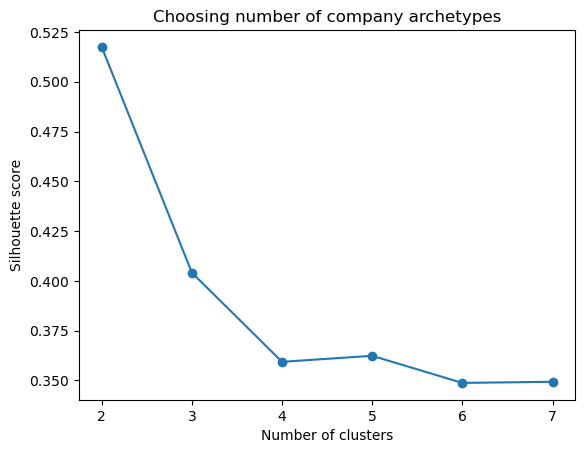


Cluster Profiles:
                  rating_work_life_balance  rating_career_opportunities  \
company_cluster                                                          
0                                    4.74                         4.71   
1                                    1.81                         1.58   
2                                    3.55                         3.38   

                 rating_compensation_and_benefits  rating_senior_leadership  \
company_cluster                                                               
0                                            4.57                      4.76   
1                                            1.85                      1.26   
2                                            3.33                      3.18   

                 rating_culture_and_values  
company_cluster                             
0                                     4.87  
1                                     1.46  
2                                

In [28]:
# Cluster Company Archetypes-real
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


In [32]:
# Sentiment distribution-real
summary_sentiment_dist = (
    df_sample_matched["summary_sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(summary_sentiment_dist)


summary_sentiment
positive    47.970309
neutral     28.717235
negative    23.312457
Name: proportion, dtype: float64


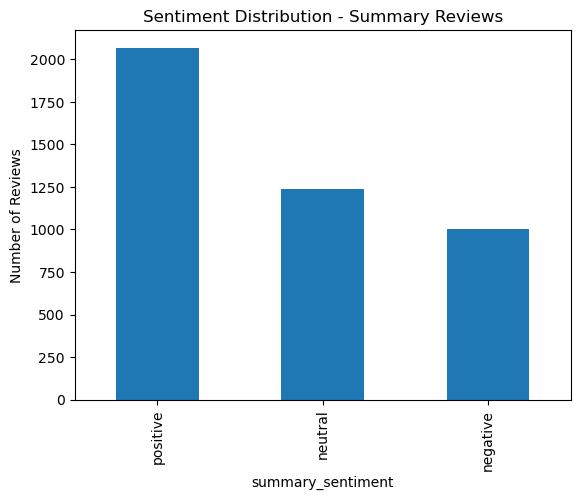

In [33]:
# Visualization of sentiment distribution-real
import matplotlib.pyplot as plt

df_sample_matched["summary_sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution - Summary Reviews")
plt.ylabel("Number of Reviews")
plt.show()

In [34]:
# Average Rating per Sentiment Category to verify the sentiment-real
df_sample_matched.groupby("summary_sentiment")["rating_overall"].mean()

summary_sentiment
negative    1.801990
neutral     3.187399
positive    4.370890
Name: rating_overall, dtype: float64

In [35]:
# Use the sentiment analysis from before to identify the sentiment distribution by employee persona and company archetype-real (matched sample)
sentiment_combo = (
    df_sample_matched
    .groupby(["employee_persona", "company_archetype"])["summary_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index(name="Percentage")
)
sentiment_combo

,employee_persona,company_archetype,summary_sentiment,Percentage
0,Active Mid-Level Employee,Average Workplace Company,positive,53.60
1,Active Mid-Level Employee,Average Workplace Company,neutral,36.80
2,Active Mid-Level Employee,Average Workplace Company,negative,9.60
3,Active Mid-Level Employee,Challenging Workplace Company,negative,59.40
4,Active Mid-Level Employee,Challenging Workplace Company,neutral,32.80
5,Active Mid-Level Employee,Challenging Workplace Company,positive,7.80
6,Active Mid-Level Employee,Top Employer Company,positive,78.40
7,Active Mid-Level Employee,Top Employer Company,neutral,20.80
8,Active Mid-Level Employee,Top Employer Company,negative,0.80
9,Former Employee,Average Workplace Company,positive,50.60


In [134]:
# Easier to read sentiment per combination of employee persona and company type-real
sentiment_combo_table = sentiment_combo.pivot_table(
    index=["employee_persona", "company_archetype"],
    columns="summary_sentiment",
    values="Percentage",
    fill_value=0
)
sentiment_combo_table

summary_sentiment                                        negative  neutral  \
employee_persona          company_archetype                                  
Active Mid-Level Employee Average Workplace Company          9.60    36.80   
                          Challenging Workplace Company     59.40    32.80   
                          Top Employer Company               0.80    20.80   
Former Employee           Average Workplace Company         16.00    33.40   
                          Challenging Workplace Company     65.80    26.80   
                          Top Employer Company               1.40    17.40   
Long-Tenure Veteran       Average Workplace Company         13.80    36.80   
                          Challenging Workplace Company     52.73    38.26   
                          Top Employer Company               1.40    19.00   

summary_sentiment                                        positive  
employee_persona          company_archetype                        
Active Mid-Level Employee Average Workplace Company          53.6  
                          Challenging Workplace Company       7.8  
                          Top Employer Company               78.4  
Former Employee           Average Workplace Company          50.6  
                          Challenging Workplace Company       7.4  
                          Top Employer Company               81.2  
Long-Tenure Veteran       Average Workplace Company          49.4  
                          Challenging Workplace Company       9.0  
                          Top Employer Company               79.6

In [37]:
# Sentiments per combination and label-real
sentiment_combo_table["overall_sentiment"] = (
    sentiment_combo_table[
        ["negative", "neutral", "positive"]
    ].idxmax(axis=1)
)

sentiment_combo_table

summary_sentiment                                        negative  neutral  \
employee_persona          company_archetype                                  
Active Mid-Level Employee Average Workplace Company          9.36    33.10   
                          Challenging Workplace Company     59.19    31.85   
                          Top Employer Company               0.83    18.60   
Former Employee           Average Workplace Company         14.97    32.67   
                          Challenging Workplace Company     63.92    28.52   
                          Top Employer Company               1.78    16.66   
Long-Tenure Veteran       Average Workplace Company         14.29    36.09   
                          Challenging Workplace Company     52.73    38.26   
                          Top Employer Company               1.16    19.50   

summary_sentiment                                        positive  \
employee_persona          company_archetype                         
Active Mid-Level Employee Average Workplace Company         57.54   
                          Challenging Workplace Company      8.96   
                          Top Employer Company              80.57   
Former Employee           Average Workplace Company         52.36   
                          Challenging Workplace Company      7.56   
                          Top Employer Company              81.56   
Long-Tenure Veteran       Average Workplace Company         49.62   
                          Challenging Workplace Company      9.00   
                          Top Employer Company              79.34   

summary_sentiment                                       overall_sentiment  
employee_persona          company_archetype                                
Active Mid-Level Employee Average Workplace Company              positive  
                          Challenging Workplace Company          negative  
                          Top Employer Company                   positive  
Former Employee           Average Workplace Company              positive  
                          Challenging Workplace Company          negative  
                          Top Employer Company                   positive  
Long-Tenure Veteran       Average Workplace Company              positive  
                          Challenging Workplace Company          negative  
                          Top Employer Company                   positive

In [37]:
# Topic modeling per employee persona × company archetype combination-real
def run_bertopic_by_group(df, text_col, group_cols):
    results = {}
    for group_values, group_df in df.groupby(group_cols):
        docs = (
            group_df[text_col]
            .dropna()
            .astype(str)
            .tolist()
        )
        print(f"Running BERTopic for {group_values} | documents: {len(docs)}")
        try:
            topic_model = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                vectorizer_model=vectorizer_model,
                representation_model=representation_model,
                calculate_probabilities=False,
                verbose=False
            )
            topics, probs = topic_model.fit_transform(docs)
            topic_info = topic_model.get_topic_info()
            results[group_values] = topic_info
        except Exception as e:
            print(f"Error for {group_values}: {e}")
            continue
    return results

In [38]:
# Show topics discussed the most in Summary review per combination-real (matched sample)
summary_topics_by_combo = run_bertopic_by_group(
    df=df_sample_matched,
    text_col="summary_clean",
    group_cols=["employee_persona", "company_archetype"]
)
# Show topics discussed the most in pros per combination-real (matched sample)
pros_topics_by_combo = run_bertopic_by_group(
    df=df_sample_matched,
    text_col="pros_clean",
    group_cols=["employee_persona", "company_archetype"]
)
# Show topics discussed the most in cons per combination-real (matched sample)
cons_topics_by_combo = run_bertopic_by_group(
    df=df_sample_matched,
    text_col="cons_clean",
    group_cols=["employee_persona", "company_archetype"]
)

Running BERTopic for ('Active Mid-Level Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Former Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Challenging Workplace Company') | documents: 311
Running BERTopic for ('Long-Tenure Veteran', 'Top Employer Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Challenging Workplace Company

In [39]:
# Extract all topics for all combinations into one table-real for review summary-real
for combo, topic_info in summary_topics_by_combo.items():

    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)

    display(
        topic_info[
            topic_info["Topic"] != -1
        ][["Topic", "Count", "Name", "Representation"]]
    )
    


Employee Persona: Active Mid-Level Employee
Company Archetype: Average Workplace Company


,Topic,Count,Name,Representation
1,0,73,0_industry_love_startup_decent,"[industry, love, startup, decent, midsized, op..."
2,1,73,1_experience_grow_engineer_freshers,"[experience, grow, engineer, freshers, technic..."
3,2,61,2_place_work_grate_foundever,"[place, work, grate, foundever, backwater, lat..."
4,3,52,3_rough_labyrinth_reshape_journey,"[rough, labyrinth, reshape, journey, mix, olx,..."
5,4,41,4_employer_salary_increase_decent,"[employer, salary, increase, decent, joke, per..."
6,5,27,5_environment_growth_opportunities_professional,"[environment, growth, opportunities, professio..."
7,6,22,6_company_nice_compamy_,"[company, nice, compamy, , , , , , , , , , , ,..."
8,7,21,7_balance_worklife_affect_goo,"[balance, worklife, affect, goo, balanace, exc..."
9,8,21,8_culture_poor_work_acquisitiondriven,"[culture, poor, work, acquisitiondriven, compa..."
10,9,21,9_supportive_leadership_room_opportunities,"[supportive, leadership, room, opportunities, ..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,65,0_place_work_engineer_experience,"[place, work, engineer, experience, learn, com..."
2,1,48,1_toxic_culture_workplace_stressnice,"[toxic, culture, workplace, stressnice, niche,..."
3,2,45,2_low_industry_dont_wages,"[low, industry, dont, wages, residual, todemot..."
4,3,30,3_worst_service_sell_team,"[worst, service, sell, team, ceo, companies, i..."
5,4,25,4_number_massmutual_alright_hype,"[number, massmutual, alright, hype, hour, chan..."
6,5,25,5_leadership_lack_poor_legacy,"[leadership, lack, poor, legacy, focus, layoff..."
7,6,20,6_growth_career_average_buffer,"[growth, career, average, buffer, onboarding, ..."
8,7,17,7_greed_corporate_day_favoritism,"[greed, corporate, day, favoritism, decline, a..."
9,8,17,8_management_wealth_theyre_costic,"[management, wealth, theyre, costic, incompete..."
10,9,17,9_time_waste_fast_run,"[time, waste, fast, run, star, pace, opposite,..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Top Employer Company


...

,Topic,Count,Name,Representation
1,0,90,0_growth_stable_corporate_overall,"[growth, stable, corporate, overall, better, b..."
2,1,44,1_place_ceiling_car_hertz,"[place, ceiling, car, hertz, wonderful, day, c..."
3,2,42,2_employer_profile_miss_medicine,"[employer, profile, miss, medicine, insurance,..."
4,3,38,3_pay_benefits_culture_cons,"[pay, benefits, culture, cons, requirements, p..."
5,4,33,4_customer_hr_department_shell,"[customer, hr, department, shell, offshore, so..."
6,5,31,5_place_decent_problems_youll,"[place, decent, problems, youll, project, anim..."
7,6,23,6_opportunity_training_welcoming_graduate,"[opportunity, training, welcoming, graduate, p..."
8,7,22,7_political_schedule_bs_fastpaced,"[political, schedule, bs, fastpaced, workload,..."
9,8,21,8_hell_looking_short_positions,"[hell, looking, short, positions, specjal, bal..."
10,9,19,9_rewarding_family_assignments_challenging,"[rewarding, family, assignments, challenging, ..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,77,0_ship_compensation_bank_outsourcing,"[ship, compensation, bank, outsourcing, beware..."
2,1,51,1_leadership_toxic_environment_dysfunctional,"[leadership, toxic, environment, dysfunctional..."
3,2,38,2_worth_used_join_flags,"[worth, used, join, flags, cons, aid, live, re..."
4,3,35,3_place_school_wasnt_rural,"[place, school, wasnt, rural, floor, medicore,..."
5,4,27,4_walk_descending_hill_misalignment,"[walk, descending, hill, misalignment, offs, p..."
6,5,25,5_culture_worklife_security_innovation,"[culture, worklife, security, innovation, tran..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Top Employer Company


,Topic,Count,Name,Representation
0,0,237,0_culture_growth_opportunities_workplace,"[culture, growth, opportunities, workplace, ba..."
1,1,79,1_place_work_cad_salespeople,"[place, work, cad, salespeople, fo, khodiyar, ..."
2,2,76,2_company_love_recommend_exposure,"[company, love, recommend, exposure, global, i..."
3,3,30,3_company_great_awesome_people,"[company, great, awesome, people, wonderful, t..."
4,4,22,4_youd_posting_perfection_food,"[youd, posting, perfection, food, expect, effi..."
5,5,21,5_place_work_best_home,"[place, work, best, home, wouldnt, st, louis, ..."
6,6,19,6_place_community_tonwork_hierachy,"[place, community, tonwork, hierachy, flat, wp..."
7,7,16,7_good_company_atmosphere_progression,"[good, company, atmosphere, progression, fair,..."


In [40]:
import pickle
with open("summary_topics_by_combo.pkl", "wb") as f:
    pickle.dump(summary_topics_by_combo, f)

In [41]:
# Extract all topics for all combinations into one table-real for pros-real
print("\n" + "#"*100)
print("PROS TOPICS")
print("#"*100)
for combo, topic_info in pros_topics_by_combo.items():
    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)
    display(
        topic_info[topic_info["Topic"] != -1]
        .sort_values("Count", ascending=False)
        .head(10)
    )

# Extract all topics for all combinations into one table-real for cons-real
print("\n" + "#"*100)
print("CONS TOPICS")
print("#"*100)
for combo, topic_info in cons_topics_by_combo.items():
    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)
    display(
        topic_info[topic_info["Topic"] != -1]
        .sort_values("Count", ascending=False)
        .head(10)
    )


####################################################################################################
PROS TOPICS
####################################################################################################

Employee Persona: Active Mid-Level Employee
Company Archetype: Average Workplace Company


,Topic,Count,Name,Representation,Representative_Docs
1,0,103,0_company_leadership_opportunities_culture,"[company, leadership, opportunities, culture, ...",[the best part of working here is the leadersh...
2,1,86,1_salary_benefits_decent_opportunities,"[salary, benefits, decent, opportunities, got,...",[good job opportunities very competitive salar...
3,2,50,2_balance_worklife_security_flexible,"[balance, worklife, security, flexible, leave,...","[work life balance is great, work life balance..."
4,3,46,3_flexible_shift_salary_facility,"[flexible, shift, salary, facility, unlimited,...",[able to work remote and gives annual bonus fl...
5,4,37,4_exposure_collaboration_global_diverse,"[exposure, collaboration, global, diverse, cul...",[incredible exposure to cuttingedge technologi...
6,5,26,5_seniors_welcoming_opportunities_colleagues,"[seniors, welcoming, opportunities, colleagues...",[nice colleagues good as a graduate got friend...
7,6,20,6_cafeteria_facilities_fun_seasonsal,"[cafeteria, facilities, fun, seasonsal, superv...",[nice coworkers nice cafeteria close to downto...
8,7,16,7_culture_office_coast_ambient,"[culture, office, coast, ambient, challenge, d...",[good wlb good culture nice environment team n...
9,8,16,8_remote_management_flexible_shifts,"[remote, management, flexible, shifts, meeting...",[remote work open communication with managemen...



Employee Persona: Active Mid-Level Employee
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation,Representative_Docs
1,0,428,0_work_benefits_free_balance,"[work, benefits, free, balance, decent, life, ...","[good work life balance nothing else, great wo..."
2,1,32,1_pro_day_work_site,"[pro, day, work, site, hrs, benefit, hours, nd...","[no pros in this company, no pros in this comp..."
3,2,17,2_professionalism_nonenot_tickets_considered,"[professionalism, nonenot, tickets, considered...","[none that i can think of, not any that i can ..."
4,3,15,3_say_waste_positive_failhr,"[say, waste, positive, failhr, smiles, sufferi...","[nothing positive to say about them, maybe jus..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Top Employer Company


...

,Topic,Count,Name,Representation,Representative_Docs
1,0,112,0_balance_hours_cons_challenging,"[balance, hours, cons, challenging, environmen...","[salary low work life balance promotion, work ..."
2,1,111,1_salary_raises_lower_benefits,"[salary, raises, lower, benefits, performance,...","[lack of bonuses low salary, after having my m..."
3,2,81,2_leadership_changes_processes_lack,"[leadership, changes, processes, lack, underst...",[the leadership changes since have resulted in...
4,3,47,3_growth_business_opportunities_jobs,"[growth, business, opportunities, jobs, amazon...",[limited career growth opportunities limited p...
5,4,32,4_care_administration_bureaucracy_approaches,"[care, administration, bureaucracy, approaches...",[bureaucracy dysfunctional funding approaches ...



Employee Persona: Long-Tenure Veteran
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation,Representative_Docs
1,0,132,0_staff_poor_hr_environment,"[staff, poor, hr, environment, balance, issues...",[despite dedicating a significant portion of m...
2,1,105,1_leadership_culture_ceo_new,"[leadership, culture, ceo, new, teams, worse, ...",[suffering from a business decline gallup does...
3,2,15,2_promoted_salon_judge_snitch,"[promoted, salon, judge, snitch, pathlack, mob...",[low compensationdelayed role promotionstoo ma...



Employee Persona: Long-Tenure Veteran
Company Archetype: Top Employer Company


,Topic,Count,Name,Representation,Representative_Docs
1,0,227,0_need_times_processes_growth,"[need, times, processes, growth, opportunities...",[less opportunities to grow no work life balan...
2,1,60,1_companies_negative_employees_culture,"[companies, negative, employees, culture, like...",[in the end hach is still a large company in a...
3,2,41,2_cons_drawbacks_holidays_review,"[cons, drawbacks, holidays, review, major, pto...","[cant think of any cons, i cant think of any c..."
4,3,40,3_place_cons_business_environment,"[place, cons, business, environment, experienc...","[none its a great place to work, no cons great..."
5,4,40,4_benefits_salaries_lower_state,"[benefits, salaries, lower, state, economy, co...",[salary a bit least competitive compared to ot...
6,5,23,5_report_share_happy_complain,"[report, share, happy, complain, significant, ...","[nothing i can think of yet, nothing i can thi..."
7,6,19,6_enjoy_worthy_spring_recollect,"[enjoy, worthy, spring, recollect, amazing, mi...","[none that i can think of, none that i can thi..."
8,7,15,7_parking_wish_convenient_downtown,"[parking, wish, convenient, downtown, franklin...",[commission split it high parking in downtown ...


In [42]:
# Define employee personas and company types-real
employee_personas = [
    "Active Mid-Level Employee",
    "Former Employee",
    "Long-Tenure Veteran"
]

company_archetypes = [
    "Top Employer Company",
    "Average Workplace Company",
    "Challenging Workplace Company"
]

In [43]:
#Install open ai
!pip install openai

In [44]:
from openai import OpenAI
import pandas as pd
import json
import time
client = OpenAI(api_key="YOUR_API_KEY_HERE")

In [45]:
# Define the generation reviews process-synthetic
def generate_reviews_batch(persona, archetype, n_reviews=10):

    prompt = f"""
You are a {persona} working for a {archetype}.

Generate {n_reviews} natural and realistic employee reviews similar to those found on Glassdoor.

Requirements:
- Use a natural and authentic tone.
- Use a writing style commonly found on employee review platforms.
- Reflect this employee persona and company archetype.
- Do not mention specific company names, industries, or personal names.
- Do not use bullet points within the reviews.
- Avoid overly formal, exaggerated, or repetitive language.
- Keep each review concise and realistic.
- Ensure that each review is unique.

Return ONLY a valid JSON object in this format:

{{
  "reviews": [
    {{
      "summary": "",
      "pros": "",
      "cons": ""
    }}
  ]
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        response_format={"type": "json_object"}
    )

    return response.choices[0].message.content

In [46]:
# Review generation-synthetic-run only once
synthetic_dfs = {}
 
n_per_combination = 500
batch_size = 10

for persona in employee_personas:
    for archetype in company_archetypes:

        combo_name = f"{persona}__{archetype}"
        combo_reviews = []

        print(f"Generating: {combo_name}")

        for i in range(0, n_per_combination, batch_size):

            try:
                review_text = generate_reviews_batch(
                    persona,
                    archetype,
                    n_reviews=batch_size
                )

                review_json = json.loads(review_text)

                for r in review_json["reviews"]:

                    combo_reviews.append({
                        "employee_persona": persona,
                        "company_archetype": archetype,
                        "review_summary_syn": r.get("summary", ""),
                        "review_pros_syn": r.get("pros", ""),
                        "review_cons_syn": r.get("cons", "")
                    })

            except Exception as e:
                print(f"Error at {combo_name}, batch {i}: {e}")

            time.sleep(0.1)

        synthetic_dfs[combo_name] = pd.DataFrame(combo_reviews)

Generating: Active Mid-Level Employee__Top Employer Company


KeyboardInterrupt: 

In [50]:
# Merge the reviews in one df-run only once
synthetic_df = pd.concat(
    synthetic_dfs.values(),
    ignore_index=True
)

In [52]:
# Save the df-run only once
synthetic_df.to_csv("synthetic_reviews.csv", index=False)

In [47]:
#Load the df
synthetic_df = pd.read_csv("synthetic_reviews.csv")

In [48]:
# Print the number of reviews generated per combination
print(synthetic_df.shape)
print(synthetic_df.groupby(['employee_persona', 'company_archetype']).size())

(4500, 5)
employee_persona           company_archetype            
Active Mid-Level Employee  Average Workplace Company        500
                           Challenging Workplace Company    500
                           Top Employer Company             500
Former Employee            Average Workplace Company        500
                           Challenging Workplace Company    500
                           Top Employer Company             500
Long-Tenure Veteran        Average Workplace Company        500
                           Challenging Workplace Company    500
                           Top Employer Company             500
dtype: int64


In [49]:
# Clean Text in syntehtic review data-syntehtic
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

synthetic_df["summary_clean_syn"] = synthetic_df["review_summary_syn"].apply(clean_text)
synthetic_df["pros_clean_syn"] = synthetic_df["review_pros_syn"].apply(clean_text)
synthetic_df["cons_clean_syn"] = synthetic_df["review_cons_syn"].apply(clean_text)

In [50]:
# Duplicate check on synthetic reviews-synthetic
print("=== DUPLICATE CHECK ===")
print("Duplicate summaries:", synthetic_df.duplicated(subset=['summary_clean_syn']).sum())
print("Duplicate pros:", synthetic_df.duplicated(subset=['pros_clean_syn']).sum())
print("Duplicate cons:", synthetic_df.duplicated(subset=['cons_clean_syn']).sum())
print("Total reviews:", len(synthetic_df))

=== DUPLICATE CHECK ===
Duplicate summaries: 1450
Duplicate pros: 24
Duplicate cons: 132
Total reviews: 4500


In [51]:
# Check review length of the cleaned text-synthetic
synthetic_df["summary_length"] = synthetic_df["summary_clean_syn"].apply(lambda x: len(x.split()))
synthetic_df["pros_length"] = synthetic_df["pros_clean_syn"].apply(lambda x: len(x.split()))
synthetic_df["cons_length"] = synthetic_df["cons_clean_syn"].apply(lambda x: len(x.split()))

synthetic_df[["summary_length", "pros_length", "cons_length"]].describe()

,summary_length,pros_length,cons_length
count,4500.000000,4500.000000,4500.000000
mean,5.715778,15.844667,13.804000
std,1.674932,4.415727,3.612699
min,2.000000,4.000000,4.000000
25%,5.000000,13.000000,11.000000
50%,6.000000,16.000000,14.000000
75%,7.000000,19.000000,16.000000
max,12.000000,35.000000,30.000000


In [52]:
# Check top words of synthetic reviews-synthetic
from collections import Counter

print("TOP WORDS - SUMMARY")
all_words_summary = " ".join(synthetic_df["summary_clean_syn"].dropna()).split()
print(Counter(all_words_summary).most_common(50))

print("\nTOP WORDS - PROS")
all_words_pros = " ".join(synthetic_df["pros_clean_syn"].dropna()).split()
print(Counter(all_words_pros).most_common(50))

print("\nTOP WORDS - CONS")
all_words_cons = " ".join(synthetic_df["cons_clean_syn"].dropna()).split()
print(Counter(all_words_cons).most_common(50))

TOP WORDS - SUMMARY
[('but', 2191), ('a', 1421), ('for', 890), ('place', 732), ('to', 608), ('good', 588), ('with', 573), ('great', 490), ('work', 448), ('environment', 423), ('not', 393), ('decent', 378), ('experience', 377), ('improvement', 336), ('room', 331), ('challenging', 302), ('growth', 298), ('mixed', 267), ('supportive', 253), ('of', 252), ('workplace', 248), ('team', 245), ('job', 243), ('needs', 242), ('solid', 235), ('bag', 229), ('rewarding', 227), ('culture', 225), ('be', 219), ('management', 204), ('some', 201), ('potential', 199), ('career', 194), ('and', 187), ('can', 185), ('overall', 185), ('high', 178), ('the', 178), ('worklife', 166), ('balance', 165), ('innovative', 162), ('better', 161), ('grow', 161), ('your', 161), ('is', 160), ('colleagues', 152), ('could', 149), ('benefits', 143), ('experiences', 143), ('challenges', 124)]

TOP WORDS - PROS
[('the', 4527), ('and', 4154), ('is', 2540), ('a', 2190), ('to', 1971), ('are', 1622), ('i', 1309), ('of', 1160), ('wo

In [53]:
# Apply RoBERTa sentiment analysis to all synthetic review summaries-syntehtic
from tqdm import tqdm

texts_syn = synthetic_df["summary_clean_syn"].astype(str).tolist()
all_results_syn = []
for i in tqdm(range(0, len(texts_syn), 64)):
    batch = texts_syn[i:i+64]
    results = sentiment_model(batch, truncation=True)
    all_results_syn.extend(results)

synthetic_df["summary_sentiment"] = [r["label"].lower() for r in all_results_syn]
synthetic_df["summary_confidence"] = [r["score"] for r in all_results_syn]

100%|███████████████████████████████████████████| 71/71 [01:27<00:00,  1.23s/it]


In [54]:
# Overall sentiment distribution of synthetic reviews in review summary-syntehtic

sentiment_counts = synthetic_df["summary_sentiment"].value_counts()
sentiment_percent = synthetic_df["summary_sentiment"].value_counts(normalize=True) * 100

sentiment_table = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": sentiment_percent.round(2)
})

sentiment_table

,Count,Percentage
summary_sentiment,,
positive,2267,50.38
neutral,1621,36.02
negative,612,13.60


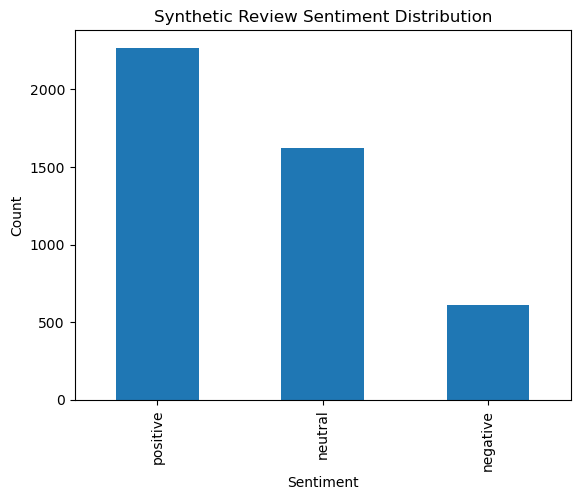

In [55]:
# Visualize overall sentiment distribution-syntehtic
import matplotlib.pyplot as plt
sentiment_counts.plot(kind="bar")

plt.title("Synthetic Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [56]:
# Sentiment distribution by employee persona and company archetype-synthetic
sentiment_combo_table_syn = pd.crosstab(
    [synthetic_df["employee_persona"],
     synthetic_df["company_archetype"]],
    synthetic_df["summary_sentiment"],
    normalize="index"
) * 100

sentiment_combo_table_syn.round(2)

summary_sentiment                                        negative  neutral  \
employee_persona          company_archetype                                  
Active Mid-Level Employee Average Workplace Company          15.6     31.0   
                          Challenging Workplace Company      10.0     44.4   
                          Top Employer Company                4.6     30.0   
Former Employee           Average Workplace Company          23.6     47.0   
                          Challenging Workplace Company      23.6     41.8   
                          Top Employer Company                9.0     27.8   
Long-Tenure Veteran       Average Workplace Company          19.8     38.2   
                          Challenging Workplace Company      11.8     41.6   
                          Top Employer Company                4.4     22.4   

summary_sentiment                                        positive  
employee_persona          company_archetype                        
Active Mid-Level Employee Average Workplace Company          53.4  
                          Challenging Workplace Company      45.6  
                          Top Employer Company               65.4  
Former Employee           Average Workplace Company          29.4  
                          Challenging Workplace Company      34.6  
                          Top Employer Company               63.2  
Long-Tenure Veteran       Average Workplace Company          42.0  
                          Challenging Workplace Company      46.6  
                          Top Employer Company               73.2

In [57]:
# Assign overall sentiment label

sentiment_combo_table_syn["overall_sentiment"] = (
    sentiment_combo_table_syn[
        ["negative", "neutral", "positive"]
    ]
    .idxmax(axis=1)
)

sentiment_combo_table_syn

summary_sentiment                                        negative  neutral  \
employee_persona          company_archetype                                  
Active Mid-Level Employee Average Workplace Company          15.6     31.0   
                          Challenging Workplace Company      10.0     44.4   
                          Top Employer Company                4.6     30.0   
Former Employee           Average Workplace Company          23.6     47.0   
                          Challenging Workplace Company      23.6     41.8   
                          Top Employer Company                9.0     27.8   
Long-Tenure Veteran       Average Workplace Company          19.8     38.2   
                          Challenging Workplace Company      11.8     41.6   
                          Top Employer Company                4.4     22.4   

summary_sentiment                                        positive  \
employee_persona          company_archetype                         
Active Mid-Level Employee Average Workplace Company          53.4   
                          Challenging Workplace Company      45.6   
                          Top Employer Company               65.4   
Former Employee           Average Workplace Company          29.4   
                          Challenging Workplace Company      34.6   
                          Top Employer Company               63.2   
Long-Tenure Veteran       Average Workplace Company          42.0   
                          Challenging Workplace Company      46.6   
                          Top Employer Company               73.2   

summary_sentiment                                       overall_sentiment  
employee_persona          company_archetype                                
Active Mid-Level Employee Average Workplace Company              positive  
                          Challenging Workplace Company          positive  
                          Top Employer Company                   positive  
Former Employee           Average Workplace Company               neutral  
                          Challenging Workplace Company           neutral  
                          Top Employer Company                   positive  
Long-Tenure Veteran       Average Workplace Company              positive  
                          Challenging Workplace Company          positive  
                          Top Employer Company                   positive

In [58]:
# BERTopic to identify topics discussed in synthetic reviews
def run_bertopic(docs, name):

    # BERTopic model
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        verbose=True
    )

    # Fit model
    topics, probs = topic_model.fit_transform(docs)

    # Reduce number of topics
    topic_model = topic_model.reduce_topics(
        docs,
        nr_topics=20
    )

    # Show topics
    print(f"\n{name} TOPICS")
    display(topic_model.get_topic_info())
    
    return topic_model, topics

In [64]:
# BERTopic on synthetic review summaries-synthetic

summary_docs_syn = synthetic_df["summary_clean_syn"].dropna().tolist()

summary_topic_model_syn, summary_topics_syn = run_bertopic(
    summary_docs_syn,
    "SYNTHETIC SUMMARY"
)

2026-07-19 12:02:05,806 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

2026-07-19 12:02:12,057 - BERTopic - Embedding - Completed ✓
2026-07-19 12:02:12,057 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 12:02:17,143 - BERTopic - Dimensionality - Completed ✓
2026-07-19 12:02:17,143 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 12:02:17,223 - BERTopic - Cluster - Completed ✓
2026-07-19 12:02:17,227 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:02:20,512 - BERTopic - Representation - Completed ✓
2026-07-19 12:02:20,592 - BERTopic - Topic reduction - Reducing number of topics
2026-07-19 12:02:20,602 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:02:21,164 - BERTopic - Representation - Completed ✓
2026-07-19 12:02:21,165 - BERTopic - Topic reduction - Reduced number of topics from 130 to 20



SYNTHETIC SUMMARY TOPICS


,Topic,Count,Name,Representation,Representative_Docs
0,-1,462,-1_worklife_balance_experience_decent,"[worklife, balance, experience, decent, bag, e...","[a good place for worklife balance, decent pla..."
1,0,849,0_grow_career_entrylevel_longterm,"[grow, career, entrylevel, longterm, stepping,...","[great place to grow your career, great place ..."
2,1,715,1_supportive_culture_leadership_diverse,"[supportive, culture, leadership, diverse, env...","[supportive team culture, supportive team cult..."
3,2,694,2_workplace_needs_stable_potential,"[workplace, needs, stable, potential, average,...",[workplace has potential but needs improvement...
4,3,300,3_rewarding_experience_worth_grind,"[rewarding, experience, worth, grind, challeng...","[challenging but rewarding, challenging but re..."
5,4,284,4_experiences_overall_average_positive,"[experiences, overall, average, positive, flaw...","[a mixed bag of experiences, a mixed bag of ex..."
6,5,233,5_innovative_projects_environment_atmosphere,"[innovative, projects, environment, atmosphere...","[innovative projects, innovative projects, inn..."
7,6,223,6_benefits_management_needs_experience,"[benefits, management, needs, experience, impr...","[good benefits but room for improvement, good ..."
8,7,215,7_worklife_balance_options_flexibility,"[worklife, balance, options, flexibility, sche...","[flexible worklife balance, flexible worklife ..."
9,8,144,8_growth_cost_opportunities_room,"[growth, cost, opportunities, room, environmen...",[potential for growth but challenging environm...


In [66]:
#BERTopic on synthetic review pros-synthetic

pros_docs_syn = synthetic_df["pros_clean_syn"].dropna().tolist()

pros_topic_model_syn, pros_topics_syn = run_bertopic(
    pros_docs_syn,
    "SYNTHETIC PROS"
)

2026-07-19 12:03:52,199 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

2026-07-19 12:03:55,973 - BERTopic - Embedding - Completed ✓
2026-07-19 12:03:55,973 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 12:04:00,322 - BERTopic - Dimensionality - Completed ✓
2026-07-19 12:04:00,323 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 12:04:00,390 - BERTopic - Cluster - Completed ✓
2026-07-19 12:04:00,391 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:04:02,685 - BERTopic - Representation - Completed ✓
2026-07-19 12:04:02,755 - BERTopic - Topic reduction - Reducing number of topics
2026-07-19 12:04:02,758 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:04:03,255 - BERTopic - Representation - Completed ✓
2026-07-19 12:04:03,256 - BERTopic - Topic reduction - Reduced number of topics from 84 to 20



SYNTHETIC PROS TOPICS


,Topic,Count,Name,Representation,Representative_Docs
0,-1,909,-1_projects_hours_friendly_innovation,"[projects, hours, friendly, innovation, balanc...",[coworkers are friendly and willing to help th...
1,0,456,0_projects_creativity_ideas_cuttingedge,"[projects, creativity, ideas, cuttingedge, enc...",[theres a strong focus on innovation and creat...
2,1,418,1_culture_willing_friendly_teambuilding,"[culture, willing, friendly, teambuilding, pas...",[the team culture is fantastic everyone is wil...
3,2,402,2_training_development_mentorship_invests,"[training, development, mentorship, invests, e...",[the company really invests in employee develo...
4,3,381,3_skills_challenges_advancement_resilience,"[skills, challenges, advancement, resilience, ...",[the challenges here push you to grow and deve...
5,4,349,4_hours_flexibility_balance_commitments,"[hours, flexibility, balance, commitments, wor...",[the ability to work from home and flexible ho...
6,5,245,5_camaraderie_colleagues_enjoyable_events,"[camaraderie, colleagues, enjoyable, events, d...",[my team is fantastic we work well together an...
7,6,218,6_colleagues_teamwork_collaborative_support,"[colleagues, teamwork, collaborative, support,...",[my colleagues are incredibly supportive and t...
8,7,186,7_office_atmosphere_friendly_benefits,"[office, atmosphere, friendly, benefits, cultu...",[the office environment is generally positive ...
9,8,183,8_benefits_decent_salary_secure,"[benefits, decent, salary, secure, layoffs, in...",[job security is solid and the benefits packag...


In [67]:
# BERTopic on synthetic review cons-synthetic

cons_docs_syn = synthetic_df["cons_clean_syn"].dropna().tolist()

cons_topic_model_syn, cons_topics_syn = run_bertopic(
    cons_docs_syn,
    "SYNTHETIC CONS"
)

2026-07-19 12:04:16,212 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

2026-07-19 12:04:19,842 - BERTopic - Embedding - Completed ✓
2026-07-19 12:04:19,842 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-19 12:04:23,874 - BERTopic - Dimensionality - Completed ✓
2026-07-19 12:04:23,875 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-19 12:04:23,939 - BERTopic - Cluster - Completed ✓
2026-07-19 12:04:23,941 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:04:26,770 - BERTopic - Representation - Completed ✓
2026-07-19 12:04:26,848 - BERTopic - Topic reduction - Reducing number of topics
2026-07-19 12:04:26,851 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-19 12:04:27,384 - BERTopic - Representation - Completed ✓
2026-07-19 12:04:27,386 - BERTopic - Topic reduction - Reduced number of topics from 99 to 20



SYNTHETIC CONS TOPICS


,Topic,Count,Name,Representation,Representative_Docs
0,-1,675,-1_innovation_lead_balance_expectations,"[innovation, lead, balance, expectations, work...",[the workload can be overwhelming at times and...
1,0,725,0_leadership_direction_daytoday_disconnected,"[leadership, direction, daytoday, disconnected...",[theres a lack of clear direction from leaders...
2,1,722,1_workload_peak_balance_worklife,"[workload, peak, balance, worklife, deadlines,...",[the workload can be overwhelming especially d...
3,2,466,2_advancement_career_promotions_development,"[advancement, career, promotions, development,...",[limited career advancement and a lack of trai...
4,3,330,3_communication_departments_misunderstandings_...,"[communication, departments, misunderstandings...",[communication between departments is often la...
5,4,228,4_pressure_expectations_perform_burnout,"[pressure, expectations, perform, burnout, lea...",[management has high expectations which can cr...
6,5,202,5_repetitive_recognition_monotonous_tasks,"[repetitive, recognition, monotonous, tasks, c...",[the work can be repetitive and theres not muc...
7,6,202,6_competitive_standards_compensation_companies,"[competitive, standards, compensation, compani...",[career advancement opportunities are limited ...
8,7,170,7_decisionmaking_processes_progress_implement,"[decisionmaking, processes, progress, implemen...",[bureaucracy can slow down decisionmaking proc...
9,8,149,8_changes_chaotic_priorities_processes,"[changes, chaotic, priorities, processes, inef...",[the lack of structure can be frustrating and ...


In [68]:
#Run BERTopic on Synthetic Summaries by Combination-synthetic
summary_topics_by_combo_syn = run_bertopic_by_group(
    df=synthetic_df,
    text_col="summary_clean_syn",
    group_cols=["employee_persona", "company_archetype"],
)

Running BERTopic for ('Active Mid-Level Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Former Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Top Employer Company') | documents: 500


In [69]:
#Display topics for all combinations on summary-synthetic
for combo, topic_info in summary_topics_by_combo_syn.items():

    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)

    display(
        topic_info[
            topic_info["Topic"] != -1
        ][["Topic", "Count", "Name", "Representation"]]
    )


Employee Persona: Active Mid-Level Employee
Company Archetype: Average Workplace Company


,Topic,Count,Name,Representation
1,0,69,0_experience_flaws_average_decent,"[experience, flaws, average, decent, improveme..."
2,1,69,1_workplace_challenges_potential_drawbacks,"[workplace, challenges, potential, drawbacks, ..."
3,2,37,2_worklife_flexible_communication_innovation,"[worklife, flexible, communication, innovation..."
4,3,37,3_dynamics_lacking_leadership_culture,"[dynamics, lacking, leadership, culture, decis..."
5,4,37,4_room_communication_potential_prioritize,"[room, communication, potential, prioritize, f..."
6,5,36,5_mixed_bag_positive_feelings,"[mixed, bag, positive, feelings, enjoy, experi..."
7,6,30,6_place_work_grow_opportunities,"[place, work, grow, opportunities, promotions,..."
8,7,29,7_environment_lacks_innovative_hiccups,"[environment, lacks, innovative, hiccups, idea..."
9,8,28,8_excitement_stability_lacking_worklife,"[excitement, stability, lacking, worklife, unc..."
10,9,21,9_career_stone_stepping_start,"[career, stone, stepping, start, grads, door, ..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,66,0_opportunities_learn_experience_ambitious,"[opportunities, learn, experience, ambitious, ..."
2,1,51,1_potential_grow_room_cost,"[potential, grow, room, cost, needs, bag, mana..."
3,2,45,2_expectations_dynamics_diverse_pressure,"[expectations, dynamics, diverse, pressure, ne..."
4,3,43,3_supportive_workload_leadership_coworkers,"[supportive, workload, leadership, coworkers, ..."
5,4,38,4_creative_worklife_balance_flexible,"[creative, worklife, balance, flexible, schedu..."
6,5,32,5_rewarding_experience_exciting_challenges,"[rewarding, experience, exciting, challenges, ..."
7,6,32,6_challenging_environment_motivating_competitive,"[challenging, environment, motivating, competi..."
8,7,31,7_dynamic_environment_room_innovative,"[dynamic, environment, room, innovative, compa..."
9,8,30,8_projects_innovative_chaotic_management,"[projects, innovative, chaotic, management, in..."
10,9,26,9_culture_innovative_times_workload,"[culture, innovative, times, workload, collabo..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Top Employer Company


...

,Topic,Count,Name,Representation
1,0,54,0_career_start_beginners_point,"[career, start, beginners, point, benefits, sh..."
2,1,35,1_mixed_bag_positive_experience,"[mixed, bag, positive, experience, overall, iv..."
3,2,32,2_excitement_lacking_environment_revitalizing,"[excitement, lacking, environment, revitalizin..."
4,3,32,3_workplace_potential_needs_growth,"[workplace, potential, needs, growth, ups, acc..."
5,4,26,4_worklife_balance_stagnant_integration,"[worklife, balance, stagnant, integration, adv..."
6,5,25,5_coworkers_management_needs_step,"[coworkers, management, needs, step, improveme..."
7,6,24,6_supportive_flaws_worklife_colleagues,"[supportive, flaws, worklife, colleagues, thri..."
8,7,24,7_settle_place_stability_clock,"[settle, place, stability, clock, comfortable,..."
9,8,22,8_environment_vision_needs_foundation,"[environment, vision, needs, foundation, leade..."
10,9,21,9_job_routine_perks_reliable,"[job, routine, perks, reliable, expect, lackin..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,98,0_colleagues_supportive_needs_environment,"[colleagues, supportive, needs, environment, i..."
2,1,43,1_place_thrive_selfstarters_decent,"[place, thrive, selfstarters, decent, challeng..."
3,2,35,2_potential_improvement_needs_room,"[potential, improvement, needs, room, executio..."
4,3,31,3_experiences_mixed_years_relationship,"[experiences, mixed, years, relationship, love..."
5,4,30,4_fulfilling_challenging_rollercoaster_workplace,"[fulfilling, challenging, rollercoaster, workp..."
6,5,30,5_challenging_rewards_bag_ways,"[challenging, rewards, bag, ways, worthwhile, ..."
7,6,28,6_experience_opportunities_curve_environment,"[experience, opportunities, curve, environment..."
8,7,27,7_rewarding_demanding_stick_taxing,"[rewarding, demanding, stick, taxing, sword, t..."
9,8,27,8_grow_cost_room_stress,"[grow, cost, room, stress, challenges, heat, e..."
10,9,24,9_experience_burnout_flaws_grind,"[experience, burnout, flaws, grind, unique, ap..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Top Employer Company


,Topic,Count,Name,Representation
1,0,54,0_culture_improvement_room_innovative,"[culture, improvement, room, innovative, spiri..."
2,1,42,1_benefits_decent_improvement_growth,"[benefits, decent, improvement, growth, collea..."
3,2,39,2_rewarding_place_challenges_voice,"[rewarding, place, challenges, voice, impact, ..."
4,3,38,3_stability_place_innovation_communication,"[stability, place, innovation, communication, ..."
5,4,36,4_grow_place_start_advancement,"[grow, place, start, advancement, graduates, o..."
6,5,35,5_leadership_approachable_room_improvement,"[leadership, approachable, room, improvement, ..."
7,6,34,6_worklife_balance_priority_valued,"[worklife, balance, priority, valued, departme..."
8,7,31,7_inclusive_workplace_diversity_values,"[inclusive, workplace, diversity, values, incl..."
9,8,28,8_values_employees_entrylevel_security,"[values, employees, entrylevel, security, feed..."
10,9,28,9_positive_bag_experiences_flaws,"[positive, bag, experiences, flaws, newcomers,..."


In [70]:
# Run BERTopic on Synthetic Pros by Combination-synthetic
pros_topics_by_combo_syn = run_bertopic_by_group(
    df=synthetic_df,
    text_col="pros_clean_syn",
    group_cols=["employee_persona", "company_archetype"]
)

# Run BERTopic on Synthetic Cons by Combination
cons_topics_by_combo_syn = run_bertopic_by_group(
    df=synthetic_df,
    text_col="cons_clean_syn",
    group_cols=["employee_persona", "company_archetype"]
)

Running BERTopic for ('Active Mid-Level Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Former Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Former Employee', 'Top Employer Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Challenging Workplace Company') | documents: 500
Running BERTopic for ('Long-Tenure Veteran', 'Top Employer Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Average Workplace Company') | documents: 500
Running BERTopic for ('Active Mid-Level Employee', 'Challenging Workplace Company

In [71]:
# Display topics for all combinations - pros - synthetic
for combo, topic_info in pros_topics_by_combo_syn.items():
    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)
    display(
        topic_info[
            topic_info["Topic"] != -1
        ][["Topic", "Count", "Name", "Representation"]]
    )


Employee Persona: Active Mid-Level Employee
Company Archetype: Average Workplace Company


,Topic,Count,Name,Representation
1,0,71,0_culture_office_inclusive_spirit,"[culture, office, inclusive, spirit, teambuild..."
2,1,67,1_training_opportunities_development_mentorship,"[training, opportunities, development, mentors..."
3,2,65,2_balance_worklife_commitments_flexibility,"[balance, worklife, commitments, flexibility, ..."
4,3,39,3_benefits_security_package_stable,"[benefits, security, package, stable, environm..."
5,4,26,4_projects_challenging_diverse_opportunities,"[projects, challenging, diverse, opportunities..."
6,5,26,5_coworkers_collaborative_environment_benefits,"[coworkers, collaborative, environment, benefi..."
7,6,26,6_flexible_balance_worklife_collaborative,"[flexible, balance, worklife, collaborative, m..."
8,7,26,7_office_worklife_balance_environment,"[office, worklife, balance, environment, relax..."
9,8,25,8_camaraderie_sense_environment_events,"[camaraderie, sense, environment, events, day,..."
10,9,24,9_management_opportunities_professional_feedback,"[management, opportunities, professional, feed..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,156,0_challenges_skills_professional_advancement,"[challenges, skills, professional, advancement..."
2,1,89,1_projects_engaging_push_skills,"[projects, engaging, push, skills, intellectua..."
3,2,60,2_innovation_encourages_company_creative,"[innovation, encourages, company, creative, ex..."
4,3,59,3_willing_spirit_collaboration_easier,"[willing, spirit, collaboration, easier, teamm..."
5,4,35,4_camaraderie_enjoyable_colleagues_share,"[camaraderie, enjoyable, colleagues, share, su..."
6,5,19,5_hours_employee_manage_commitments,"[hours, employee, manage, commitments, develop..."
7,6,17,6_passionate_room_learning_seek,"[passionate, room, learning, seek, opportunity..."
8,7,17,7_passionate_driven_guidance_diversity,"[passionate, driven, guidance, diversity, boun..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Top Employer Company


...

,Topic,Count,Name,Representation
0,0,388,0_supportive_hours_balance_worklife,"[supportive, hours, balance, worklife, benefit..."
1,1,43,1_security_benefits_company_layoffs,"[security, benefits, company, layoffs, workloa..."
2,2,36,2_training_entrylevel_experience_ropes,"[training, entrylevel, experience, ropes, skil..."
3,3,33,3_camaraderie_team_enjoyable_highlight,"[camaraderie, team, enjoyable, highlight, bene..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
0,0,483,0_projects_strong_camaraderie_experience,"[projects, strong, camaraderie, experience, co..."
1,1,17,1_fastpaced_pace_moment_fast,"[fastpaced, pace, moment, fast, dull, wont, la..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Top Employer Company


,Topic,Count,Name,Representation
0,0,94,0_development_training_opportunities_mentorship,"[development, training, opportunities, mentors..."
1,1,71,1_colleagues_supportive_collaborative_friendly,"[colleagues, supportive, collaborative, friend..."
2,2,56,2_hours_balance_worklife_flexibility,"[hours, balance, worklife, flexibility, commit..."
3,3,56,3_benefits_insurance_wellness_competitive,"[benefits, insurance, wellness, competitive, o..."
4,4,45,4_diversity_inclusion_culture_perspectives,"[diversity, inclusion, culture, perspectives, ..."
5,5,42,5_feedback_leadership_approachable_genuinely,"[feedback, leadership, approachable, genuinely..."
6,6,34,6_projects_challenges_cuttingedge_grow,"[projects, challenges, cuttingedge, grow, enga..."
7,7,29,7_innovation_creativity_exciting_contribute,"[innovation, creativity, exciting, contribute,..."
8,8,28,8_job_stability_solid_layoffs,"[job, stability, solid, layoffs, secure, stay,..."
9,9,24,9_camaraderie_successes_family_culture,"[camaraderie, successes, family, culture, enjo..."


In [72]:
# Display topics for all combinations - cons - synthetic
for combo, topic_info in cons_topics_by_combo_syn.items():
    print("\n" + "="*100)
    print(f"Employee Persona: {combo[0]}")
    print(f"Company Archetype: {combo[1]}")
    print("="*100)
    display(
        topic_info[
            topic_info["Topic"] != -1
        ][["Topic", "Count", "Name", "Representation"]]
    )


Employee Persona: Active Mid-Level Employee
Company Archetype: Average Workplace Company


,Topic,Count,Name,Representation
1,0,176,0_communication_management_departments_priorities,"[communication, management, departments, prior..."
2,1,126,1_advancement_opportunities_promotions_compared,"[advancement, opportunities, promotions, compa..."
3,2,92,2_innovation_feel_projects_outdated,"[innovation, feel, projects, outdated, repetit..."
4,3,51,3_workload_overwhelming_peak_deadlines,"[workload, overwhelming, peak, deadlines, seas..."
5,4,28,4_decisionmaking_progress_timelines_projects,"[decisionmaking, progress, timelines, projects..."
6,5,16,5_daytoday_disconnected_challenges_tasks,"[daytoday, disconnected, challenges, tasks, wo..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,55,0_deadlines_workload_stress_atmosphere,"[deadlines, workload, stress, atmosphere, leve..."
2,1,45,1_lack_processes_projects_chaos,"[lack, processes, projects, chaos, inefficienc..."
3,2,41,2_balance_worklife_maintain_especially,"[balance, worklife, maintain, especially, week..."
4,3,40,3_expectations_burnout_stress_set,"[expectations, burnout, stress, set, managemen..."
5,4,40,4_management_lack_teams_feedback,"[management, lack, teams, feedback, interdepar..."
6,5,38,5_pace_burnout_balance_worklife,"[pace, burnout, balance, worklife, setting, th..."
7,6,34,6_perform_isnt_mistakes_stress,"[perform, isnt, mistakes, stress, manage, room..."
8,7,33,7_priorities_management_changes_inconsistent,"[priorities, management, changes, inconsistent..."
9,8,27,8_burnout_fastpaced_environment_workload,"[burnout, fastpaced, environment, workload, em..."
10,9,25,9_demands_workload_management_work,"[demands, workload, management, work, achievem..."



Employee Persona: Active Mid-Level Employee
Company Archetype: Top Employer Company


...

,Topic,Count,Name,Representation
1,0,141,0_advancement_opportunities_training_infrequent,"[advancement, opportunities, training, infrequ..."
2,1,91,1_communication_direction_leadership_departments,"[communication, direction, leadership, departm..."
3,2,73,2_innovation_change_ideas_stagnant,"[innovation, change, ideas, stagnant, resistan..."
4,3,43,3_projects_repetitive_work_challenging,"[projects, repetitive, work, challenging, mono..."
5,4,40,4_workload_uneven_motivation_departments,"[workload, uneven, motivation, departments, pe..."
6,5,25,5_promotions_merit_performance_tenure,"[promotions, merit, performance, tenure, disco..."
7,6,19,6_monotonous_innovation_isnt_repetitive,"[monotonous, innovation, isnt, repetitive, tas..."
8,7,17,7_decisionmaking_bureaucracy_processes_lot,"[decisionmaking, bureaucracy, processes, lot, ..."
9,8,17,8_creativity_room_monotonous_repetitive,"[creativity, room, monotonous, repetitive, are..."
10,9,16,9_outdated_processes_productivity_frustrate,"[outdated, processes, productivity, frustrate,..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Challenging Workplace Company


,Topic,Count,Name,Representation
1,0,106,0_communication_leadership_frustration_direction,"[communication, leadership, frustration, direc..."
2,1,60,1_burnout_hours_demands_worklife,"[burnout, hours, demands, worklife, lead, work..."
3,2,53,2_workload_deadlines_work_resources,"[workload, deadlines, work, resources, shortst..."
4,3,46,3_perform_atmosphere_highpressure_stress,"[perform, atmosphere, highpressure, stress, bu..."
5,4,38,4_expectations_environment_unrealistic_culture,"[expectations, environment, unrealistic, cultu..."
6,5,36,5_management_support_fires_workload,"[management, support, fires, workload, wellbei..."
7,6,28,6_processes_direction_changes_priorities,"[processes, direction, changes, priorities, di..."
8,7,25,7_balance_worklife_expectation_sacrificed,"[balance, worklife, expectation, sacrificed, o..."
9,8,22,8_daytoday_disconnected_struggles_management,"[daytoday, disconnected, struggles, management..."
10,9,18,9_guidance_newcomers_isolated_training,"[guidance, newcomers, isolated, training, onbo..."



Employee Persona: Long-Tenure Veteran
Company Archetype: Top Employer Company


,Topic,Count,Name,Representation
1,0,75,0_workload_balance_especially_peak,"[workload, balance, especially, peak, worklife..."
2,1,58,1_decisionmaking_frustrating_ideas_implement,"[decisionmaking, frustrating, ideas, implement..."
3,2,56,2_pace_innovation_lead_stability,"[pace, innovation, lead, stability, changes, b..."
4,3,54,3_management_lack_daytoday_leading,"[management, lack, daytoday, leading, prioriti..."
5,4,48,4_opportunities_advancement_promotions_ladder,"[opportunities, advancement, promotions, ladde..."
6,5,41,5_diversity_initiatives_community_noticeable,"[diversity, initiatives, community, noticeable..."
7,6,28,6_seasons_peak_overwhelming_workload,"[seasons, peak, overwhelming, workload, especi..."
8,7,26,7_departments_leading_silos_efforts,"[departments, leading, silos, efforts, collabo..."
9,8,23,8_remote_work_options_internal,"[remote, work, options, internal, collaboratio..."
10,9,21,9_deadlines_stress_expectations_unrealistic,"[deadlines, stress, expectations, unrealistic,..."


In [91]:
# LLM-based analysis function for employee reviews-LLM
import json
import pandas as pd

def llm_analyze_reviews(reviews_text, group_name):
    prompt = f"""
You are an experienced qualitative research analyst.
You are analyzing employee reviews for the group: {group_name}.
Your task is to extract employer branding insights from the reviews.
Tasks:
1. Identify the main recurring themes.
2. Summarize the main strengths mentioned by employees.
3. Summarize the main weaknesses mentioned by employees.
4. Describe the overall sentiment in a short sentence.
5. Provide a short employer branding interpretation.
6. Provide a single overall sentiment label that best summarizes point 4: choose exactly one of "positive", "neutral", or "negative".

Reviews:
{reviews_text}

Return ONLY valid JSON in this format:
{{
  "group": "{group_name}",
  "main_themes": [],
  "strengths": [],
  "weaknesses": [],
  "overall_sentiment": "",
  "overall_sentiment_label": "",
  "employer_branding_interpretation": ""
}}
"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        response_format={"type": "json_object"}
    )
    return json.loads(response.choices[0].message.content)

In [92]:
# Prepare review text for LLM analysis (150 observations per combination)-LLM

def prepare_reviews_text(df, n=150):

    sample_df = df.sample(
        n=min(n, len(df)),
        random_state=42
    )

    reviews_text = "\n\n".join(
        "Summary: " + sample_df["review_summary_syn"].astype(str) +
        "\nPros: " + sample_df["review_pros_syn"].astype(str) +
        "\nCons: " + sample_df["review_cons_syn"].astype(str)
    )

    return reviews_text

In [93]:
# Scenario 3A: LLM-based analysis of all synthetic reviews-LLM

all_reviews_text = prepare_reviews_text(
    synthetic_df,
    n=150
)

llm_all_results = llm_analyze_reviews(
    all_reviews_text,
    group_name="All Synthetic Reviews"
)

llm_all_results

{'group': 'All Synthetic Reviews',
 'main_themes': ['Supportive team environment',
  'Work-life balance',
  'Communication issues',
  'Management disconnect',
  'Opportunities for growth',
  'High workload and stress',
  'Innovation and creativity'],
 'strengths': ['Friendly and supportive colleagues',
  'Flexible work hours',
  'Opportunities for professional development',
  'Engaging and challenging projects',
  'Strong team spirit and camaraderie',
  'Diversity in the workplace'],
 'weaknesses': ['Management often seems disconnected from employees',
  'Communication between departments can be lacking',
  'High workload and pressure leading to burnout',
  'Limited opportunities for advancement',
  'Inconsistent recognition for hard work',
  'Lack of innovation and resistance to change'],
 'overall_sentiment': 'The overall sentiment reflects a mix of positive experiences and frustrations, particularly regarding management and workload.',
 'overall_sentiment_label': 'neutral',
 'employ

In [135]:
# Scenario 3D: LLM-based analysis by employee persona and company archetype combination-LLM
llm_combo_results = []
for (persona, archetype), group_df in synthetic_df.groupby(
    ["employee_persona", "company_archetype"]
):
    # Prepare review text sample for this combination
    # n=150 reviews per group as specified in the methodology
    reviews_text = prepare_reviews_text(
        group_df,
        n=150
    )
    # Run LLM-based analysis for this persona-archetype combination
    result = llm_analyze_reviews(
        reviews_text,
        group_name=f"{persona} + {archetype}"
    )
    # Tag each result with its persona and archetype for traceability
    result["employee_persona"] = persona
    result["company_archetype"] = archetype
    llm_combo_results.append(result)

# Combine all results into a single dataframe
llm_combo_results_df = pd.DataFrame(llm_combo_results)

# Print full results without truncation
for idx, row in llm_combo_results_df.iterrows():
    print(f"\n{'='*60}")
    print(f"Persona: {row['employee_persona']}")
    print(f"Archetype: {row['company_archetype']}")
    print(f"Overall sentiment: {row['overall_sentiment']}")
    print(f"Overall sentiment label: {row['overall_sentiment_label']}")
    print(f"\nMain themes:")
    for theme in row['main_themes']:
        print(f"  - {theme}")
    print(f"\nStrengths:")
    for s in row['strengths']:
        print(f"  - {s}")
    print(f"\nWeaknesses:")
    for w in row['weaknesses']:
        print(f"  - {w}")
    print(f"\nEmployer branding interpretation:")
    print(f"  {row['employer_branding_interpretation']}")


Persona: Active Mid-Level Employee
Archetype: Average Workplace Company
Overall sentiment: Employees appreciate the supportive culture and work-life balance, but express concerns over limited growth opportunities and communication issues.
Overall sentiment label: neutral

Main themes:
  - Work-life balance
  - Friendly workplace culture
  - Limited career advancement
  - Communication issues
  - Job security
  - Lack of innovation

Strengths:
  - Flexible hours and work-life balance
  - Supportive and friendly coworkers
  - Decent benefits package
  - Job security
  - Opportunities for learning and development

Weaknesses:
  - Limited growth and advancement opportunities
  - Communication from management is often lacking
  - Work can be repetitive and lack excitement
  - Outdated processes and resistance to innovation
  - Pay is not competitive

Employer branding interpretation:
  The company is perceived as a stable and friendly workplace that offers a good starting point for career 

In [95]:
# Save LLM-based analysis outputs-LLM
llm_all_results_df = pd.DataFrame([llm_all_results])

llm_all_results_df.to_csv("llm_analysis_all_synthetic_reviews.csv", index=False)
llm_combo_results_df.to_csv("llm_analysis_by_combination.csv", index=False)

In [97]:
# Print outputs-LLM
llm_all_results_df

,group,main_themes,strengths,weaknesses,overall_sentiment,overall_sentiment_label,employer_branding_interpretation
0,All Synthetic Reviews,"[Supportive team environment, Work-life balanc...","[Friendly and supportive colleagues, Flexible ...",[Management often seems disconnected from empl...,The overall sentiment reflects a mix of positi...,neutral,The company is perceived as a supportive workp...


In [98]:
# More clear output-LLM
for col in llm_all_results_df.columns:
    print(f"\n{'='*60}")
    print(f"{col.upper()}:")
    print(llm_all_results_df[col].values[0])


GROUP:
All Synthetic Reviews

MAIN_THEMES:
['Supportive team environment', 'Work-life balance', 'Communication issues', 'Management disconnect', 'Opportunities for growth', 'High workload and stress', 'Innovation and creativity']

STRENGTHS:
['Friendly and supportive colleagues', 'Flexible work hours', 'Opportunities for professional development', 'Engaging and challenging projects', 'Strong team spirit and camaraderie', 'Diversity in the workplace']

WEAKNESSES:
['Management often seems disconnected from employees', 'Communication between departments can be lacking', 'High workload and pressure leading to burnout', 'Limited opportunities for advancement', 'Inconsistent recognition for hard work', 'Lack of innovation and resistance to change']

OVERALL_SENTIMENT:
The overall sentiment reflects a mix of positive experiences and frustrations, particularly regarding management and workload.

OVERALL_SENTIMENT_LABEL:
neutral

EMPLOYER_BRANDING_INTERPRETATION:
The company is perceived as a

In [99]:
# Word count comparison between real and synthetic reviews-Comparison
# Assesses surface-level textual similarity 
import pandas as pd

def compute_word_count_stats(df, fields):
    stats = {}
    for field in fields:
        lengths = df[field].dropna().apply(lambda x: len(str(x).split()))
        stats[field] = {
            "mean": round(lengths.mean(), 2),
            "median": round(lengths.median(), 2),
            "std": round(lengths.std(), 2)
        }
    return stats

real_fields = ["summary_clean", "pros_clean", "cons_clean"]
syn_fields = ["summary_clean_syn", "pros_clean_syn", "cons_clean_syn"]

real_wc = compute_word_count_stats(df_sample_matched, real_fields)
syn_wc = compute_word_count_stats(synthetic_df, syn_fields)

print("=== WORD COUNT COMPARISON (C1 vs C2, matched sample) ===\n")
for real_f, syn_f in zip(real_fields, syn_fields):
    field_name = real_f.replace("_clean", "").replace("_syn", "")
    print(f"{field_name.upper()}")
    print(f"  Real      — Mean: {real_wc[real_f]['mean']} | Median: {real_wc[real_f]['median']} | Std: {real_wc[real_f]['std']}")
    print(f"  Synthetic — Mean: {syn_wc[syn_f]['mean']} | Median: {syn_wc[syn_f]['median']} | Std: {syn_wc[syn_f]['std']}")
    print()

=== WORD COUNT COMPARISON (C1 vs C2, matched sample) ===

SUMMARY
  Real      — Mean: 4.67 | Median: 4.0 | Std: 2.71
  Synthetic — Mean: 5.72 | Median: 6.0 | Std: 1.67

PROS
  Real      — Mean: 17.88 | Median: 9.0 | Std: 29.72
  Synthetic — Mean: 15.84 | Median: 16.0 | Std: 4.42

CONS
  Real      — Mean: 29.97 | Median: 12.0 | Std: 56.59
  Synthetic — Mean: 13.8 | Median: 14.0 | Std: 3.61



In [130]:
# Jaccard similarity between most frequent terms in real and synthetic reviews-Comparison
# Measures vocabulary overlap between datasets 
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def compute_jaccard(df_real, df_syn, field_real, field_syn, top_n=50):
    
    real_counter = Counter(
        w for w in " ".join(df_real[field_real].dropna()).split()
        if w.lower() not in ENGLISH_STOP_WORDS and len(w) > 2
    )
    syn_counter = Counter(
        w for w in " ".join(df_syn[field_syn].dropna()).split()
        if w.lower() not in ENGLISH_STOP_WORDS and len(w) > 2
    )
    
    real_words = real_counter.most_common(top_n)
    syn_words = syn_counter.most_common(top_n)
    
    real_set = set([w[0] for w in real_words])
    syn_set = set([w[0] for w in syn_words])
    
    intersection = len(real_set & syn_set)
    union = len(real_set | syn_set)
    jaccard = intersection / union
    
    # Sort overlapping/unique terms by their combined or individual frequency, not alphabetically
    overlapping_sorted = sorted(
        real_set & syn_set,
        key=lambda w: real_counter[w] + syn_counter[w],
        reverse=True
    )
    unique_to_real_sorted = sorted(
        real_set - syn_set,
        key=lambda w: real_counter[w],
        reverse=True
    )
    unique_to_synthetic_sorted = sorted(
        syn_set - real_set,
        key=lambda w: syn_counter[w],
        reverse=True
    )
    
    return {
        "jaccard_similarity": round(jaccard, 4),
        "overlapping_terms": overlapping_sorted,
        "unique_to_real": unique_to_real_sorted,
        "unique_to_synthetic": unique_to_synthetic_sorted
    }

print("=== JACCARD TERM OVERLAP (C1 vs C2) ===\n")
for real_f, syn_f in zip(real_fields, syn_fields):
    field_name = real_f.replace("_clean", "")
    result = compute_jaccard(df_sample_matched, synthetic_df, real_f, syn_f)
    print(f"{field_name.upper()}")
    print(f"  Jaccard Similarity: {result['jaccard_similarity']}")
    print(f"  Overlapping terms ({len(result['overlapping_terms'])}): {result['overlapping_terms'][:10]}...")
    print(f"  Unique to real ({len(result['unique_to_real'])}): {result['unique_to_real'][:5]}...")
    print(f"  Unique to synthetic ({len(result['unique_to_synthetic'])}): {result['unique_to_synthetic'][:5]}...")
    print()

=== JACCARD TERM OVERLAP (C1 vs C2) ===

SUMMARY
  Jaccard Similarity: 0.3333
  Overlapping terms (25): ['great', 'place', 'work', 'good', 'company', 'environment', 'experience', 'growth', 'decent', 'culture']...
  Unique to real (25): ['people', 'best', 'pay', 'working', 'life']...
  Unique to synthetic (25): ['improvement', 'room', 'challenging', 'mixed', 'needs']...

PROS
  Jaccard Similarity: 0.4085
  Overlapping terms (29): ['work', 'good', 'great', 'team', 'company', 'benefits', 'people', 'environment', 'opportunities', 'supportive']...
  Unique to real (21): ['working', 'pay', 'place', 'growth', 'time']...
  Unique to synthetic (21): ['theres', 'ive', 'appreciate', 'willing', 'help']...

CONS
  Jaccard Similarity: 0.1905
  Overlapping terms (16): ['work', 'management', 'like', 'company', 'times', 'lack', 'employees', 'pay', 'hard', 'leadership']...
  Unique to real (34): ['people', 'time', 'dont', 'job', 'working']...
  Unique to synthetic (34): ['theres', 'feels', 'feel', 'work

In [101]:
# Jensen-Shannon Divergence between sentiment distributions-Comparison
# Measures how similar sentiment distributions are across scenarios (

from scipy.spatial.distance import jensenshannon
import numpy as np

def compute_sentiment_jsd(real_sentiments, compare_sentiments, label):
    
    labels = ["positive", "neutral", "negative"]
    
    real_dist = np.array([(real_sentiments == l).mean() for l in labels])
    compare_dist = np.array([(compare_sentiments == l).mean() for l in labels])
    
    jsd = jensenshannon(real_dist, compare_dist)
    
    print(f"  {label}")
    print(f"  Real      — Positive: {real_dist[0]:.3f} | Neutral: {real_dist[1]:.3f} | Negative: {real_dist[2]:.3f}")
    print(f"  Compare   — Positive: {compare_dist[0]:.3f} | Neutral: {compare_dist[1]:.3f} | Negative: {compare_dist[2]:.3f}")
    print(f"  Jensen-Shannon Divergence: {round(jsd, 4)} (0=identical, 1=completely different)")
    print()
    
    return jsd

print("=== SENTIMENT DISTRIBUTION COMPARISON (C1 vs C2 vs C3) ===\n")

# C1 vs C2 — real vs synthetic (traditional analytics)
jsd_c1_c2 = compute_sentiment_jsd(
    df_sample_matched["summary_sentiment"],
    synthetic_df["summary_sentiment"],
    "C1 (Real, matched) vs C2 (Synthetic)"
)

=== SENTIMENT DISTRIBUTION COMPARISON (C1 vs C2 vs C3) ===

  C1 (Real, matched) vs C2 (Synthetic)
  Real      — Positive: 0.480 | Neutral: 0.287 | Negative: 0.233
  Compare   — Positive: 0.504 | Neutral: 0.360 | Negative: 0.136
  Jensen-Shannon Divergence: 0.0932 (0=identical, 1=completely different)



In [131]:
# Cosine similarity between topic keywords and proportion of theme recovery-Comparison
# Measures semantic similarity of topics between real and synthetic reviews


from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import numpy as np

def compute_topic_similarity(real_model, syn_model, field_name):
    
    # Get topic keywords excluding outlier topic (-1)
    real_topics = real_model.get_topic_info()
    real_topics = real_topics[real_topics["Topic"] != -1]["Representation"].tolist()
    
    syn_topics = syn_model.get_topic_info()
    syn_topics = syn_topics[syn_topics["Topic"] != -1]["Representation"].tolist()
    
    # Convert keyword lists to strings
    real_keywords = [" ".join(t) for t in real_topics]
    syn_keywords = [" ".join(t) for t in syn_topics]
    
    # Use semantic embeddings for meaningful topic comparison
    embed_model = SentenceTransformer("all-MiniLM-L6-v2")
    real_vecs = embed_model.encode(real_keywords)
    syn_vecs = embed_model.encode(syn_keywords)
    
    # Compute cosine similarity matrix
    similarity_matrix = cosine_similarity(real_vecs, syn_vecs)
    
    # Average maximum cosine similarity per real topic
    avg_cosine = similarity_matrix.max(axis=1).mean()
    
    # Theme recovery: % of real topics with cosine > 0.5
    recovered = sum(similarity_matrix.max(axis=1) > 0.5)
    theme_recovery = recovered / len(real_keywords)
    
    # New themes in synthetic not in real
    new_themes = sum(similarity_matrix.max(axis=0) < 0.5)
    new_themes_pct = new_themes / len(syn_keywords)
    
    print(f"=== {field_name.upper()} ===")
    print(f"  Real topics: {len(real_keywords)} | Synthetic topics: {len(syn_keywords)}")
    print(f"  Average cosine similarity: {round(avg_cosine, 4)}")
    print(f"  Theme recovery: {round(theme_recovery*100, 1)}% of real topics recovered in synthetic")
    print(f"  New themes in synthetic: {round(new_themes_pct*100, 1)}%")
    print()
    
    return {
        "field": field_name,
        "avg_cosine_similarity": round(avg_cosine, 4),
        "theme_recovery": round(theme_recovery, 4),
        "new_themes_pct": round(new_themes_pct, 4)
    }

print("=== TOPIC SIMILARITY (C1 vs C2) ===\n")

results_summary = compute_topic_similarity(topic_model_summary, summary_topic_model_syn, "summary")
results_pros = compute_topic_similarity(topic_model_pros, pros_topic_model_syn, "pros")
results_cons = compute_topic_similarity(topic_model_cons, cons_topic_model_syn, "cons")

=== TOPIC SIMILARITY (C1 vs C2) ===



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== SUMMARY ===
  Real topics: 19 | Synthetic topics: 19
  Average cosine similarity: 0.3492000102996826
  Theme recovery: 21.1% of real topics recovered in synthetic
  New themes in synthetic: 84.2%



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== PROS ===
  Real topics: 19 | Synthetic topics: 19
  Average cosine similarity: 0.46000000834465027
  Theme recovery: 42.1% of real topics recovered in synthetic
  New themes in synthetic: 47.4%



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

=== CONS ===
  Real topics: 19 | Synthetic topics: 19
  Average cosine similarity: 0.39320001006126404
  Theme recovery: 21.1% of real topics recovered in synthetic
  New themes in synthetic: 73.7%



In [107]:
# C3 vs C1 and C2: Final Comparison- Comparison
# 1. Cosine similarity + theme recovery to identify if themes are themes similar
# 2. Sentiment agreement rate (to identify if sentiment direction is correct?

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load sentence embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# =============================================================
# C3 themes, strengths and weaknesses
# Extracted by GPT-4o-mini from all synthetic reviews combined
# =============================================================

c3_all = [
    # Main themes
    "Work-life balance",
    "Team camaraderie and support",
    "Management issues",
    "Communication challenges",
    "Opportunities for growth",
    "Workload and stress levels",
    "Innovation and creativity",
    "Training and development",
    # Strengths
    "Friendly and supportive colleagues",
    "Flexible work hours",
    "Opportunities for professional development",
    "Engaging and challenging projects",
    "Strong team spirit and camaraderie",
    "Decent benefits package",
    # Weaknesses
    "Management often disconnected from employees",
    "Communication issues between departments",
    "High workload and stress levels",
    "Limited opportunities for advancement",
    "Lack of recognition for hard work",
    "Resistance to change and innovation"
]

# =============================================================
# METRIC 1: Cosine similarity + theme recovery
# =============================================================

def compare_c3_to_bertopic(c3_texts, topic_model, label):
    topic_info = topic_model.get_topic_info()
    topic_info = topic_info[topic_info["Topic"] != -1]["Representation"].tolist()
    topic_keywords = [" ".join(t) for t in topic_info]
    
    c3_vecs = embed_model.encode(c3_texts)
    topic_vecs = embed_model.encode(topic_keywords)
    
    sim_matrix = cosine_similarity(c3_vecs, topic_vecs)
    
    avg_cosine = sim_matrix.max(axis=1).mean()
    recovery = (sim_matrix.max(axis=1) >= 0.5).mean()
    not_captured = (sim_matrix.max(axis=0) < 0.5).mean()
    
    print(f"  C3 vs {label}:")
    print(f"    Average cosine similarity: {round(avg_cosine, 4)}")
    print(f"    C3 theme recovery: {round(recovery*100, 1)}%")
    print(f"    {label} topics NOT captured by C3: {round(not_captured*100, 1)}%")
    print()

print("=" * 60)
print("METRIC 1: COSINE SIMILARITY AND THEME RECOVERY")
print("=" * 60)

print("\n--- Summary Field ---")
compare_c3_to_bertopic(c3_all, topic_model_summary, "C1")
compare_c3_to_bertopic(c3_all, summary_topic_model_syn, "C2")

print("--- Pros Field ---")
compare_c3_to_bertopic(c3_all, topic_model_pros, "C1")
compare_c3_to_bertopic(c3_all, pros_topic_model_syn, "C2")

print("--- Cons Field ---")
compare_c3_to_bertopic(c3_all, topic_model_cons, "C1")
compare_c3_to_bertopic(c3_all, cons_topic_model_syn, "C2")

# =============================================================
# METRIC 2: Sentiment agreement rate
# =============================================================

# C3 — from updated LLM output (Scenario 3D, overall_sentiment_label), synthetic-based
c3_sentiment = {
    ("Active Mid-Level Employee", "Average Workplace Company"): "neutral",
    ("Active Mid-Level Employee", "Challenging Workplace Company"): "negative",
    ("Active Mid-Level Employee", "Top Employer Company"): "positive",
    ("Former Employee", "Average Workplace Company"): "neutral",
    ("Former Employee", "Challenging Workplace Company"): "negative",
    ("Former Employee", "Top Employer Company"): "positive",
    ("Long-Tenure Veteran", "Average Workplace Company"): "neutral",
    ("Long-Tenure Veteran", "Challenging Workplace Company"): "negative",
    ("Long-Tenure Veteran", "Top Employer Company"): "positive",
}

# C1 — from matched real sentiment table (df_sample_matched, sentiment_combo_table)
c1_sentiment = {
    ("Active Mid-Level Employee", "Average Workplace Company"): "positive",
    ("Active Mid-Level Employee", "Challenging Workplace Company"): "negative",
    ("Active Mid-Level Employee", "Top Employer Company"): "positive",
    ("Former Employee", "Average Workplace Company"): "positive",
    ("Former Employee", "Challenging Workplace Company"): "negative",
    ("Former Employee", "Top Employer Company"): "positive",
    ("Long-Tenure Veteran", "Average Workplace Company"): "positive",
    ("Long-Tenure Veteran", "Challenging Workplace Company"): "negative",
    ("Long-Tenure Veteran", "Top Employer Company"): "positive",
}

# C2 — synthetic sentiment, unaffected by real-data matching fix, unchanged
c2_sentiment = {
    ("Active Mid-Level Employee", "Average Workplace Company"): "positive",
    ("Active Mid-Level Employee", "Challenging Workplace Company"): "neutral",
    ("Active Mid-Level Employee", "Top Employer Company"): "positive",
    ("Former Employee", "Average Workplace Company"): "neutral",
    ("Former Employee", "Challenging Workplace Company"): "neutral",
    ("Former Employee", "Top Employer Company"): "positive",
    ("Long-Tenure Veteran", "Average Workplace Company"): "positive",
    ("Long-Tenure Veteran", "Challenging Workplace Company"): "neutral",
    ("Long-Tenure Veteran", "Top Employer Company"): "positive",
}

combos = list(c3_sentiment.keys())

c3_c1_agree = sum(c3_sentiment[k] == c1_sentiment[k] for k in combos)
c3_c2_agree = sum(c3_sentiment[k] == c2_sentiment[k] for k in combos)
c1_c2_agree = sum(c1_sentiment[k] == c2_sentiment[k] for k in combos)

print("=" * 60)
print("METRIC 2: SENTIMENT AGREEMENT RATE")
print("=" * 60)
print(f"\nC3 vs C1: {c3_c1_agree}/{len(combos)} agree ({c3_c1_agree/len(combos)*100:.1f}%)")
print(f"C3 vs C2: {c3_c2_agree}/{len(combos)} agree ({c3_c2_agree/len(combos)*100:.1f}%)")
print(f"C1 vs C2 benchmark: {c1_c2_agree}/{len(combos)} agree ({c1_c2_agree/len(combos)*100:.1f}%)")

print("\n--- Per Combination Breakdown ---\n")
print(f"{'Persona':<32} {'Archetype':<30} {'C1':<12} {'C2':<12} {'C3':<12} {'C3=C1':<8} {'C3=C2'}")
print("-" * 110)
for k in combos:
    persona, archetype = k
    c1 = c1_sentiment[k]
    c2 = c2_sentiment[k]
    c3 = c3_sentiment[k]
    print(f"{persona:<32} {archetype:<30} {c1:<12} {c2:<12} {c3:<12} {'Yes' if c3==c1 else 'No':<8} {'Yes' if c3==c2 else 'No'}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

METRIC 1: COSINE SIMILARITY AND THEME RECOVERY

--- Summary Field ---
  C3 vs C1:
    Average cosine similarity: 0.4156000018119812
    C3 theme recovery: 25.0%
    C1 topics NOT captured by C3: 84.2%

  C3 vs C2:
    Average cosine similarity: 0.398499995470047
    C3 theme recovery: 25.0%
    C2 topics NOT captured by C3: 84.2%

--- Pros Field ---
  C3 vs C1:
    Average cosine similarity: 0.38029998540878296
    C3 theme recovery: 15.0%
    C1 topics NOT captured by C3: 84.2%

  C3 vs C2:
    Average cosine similarity: 0.4593999981880188
    C3 theme recovery: 35.0%
    C2 topics NOT captured by C3: 57.9%

--- Cons Field ---
  C3 vs C1:
    Average cosine similarity: 0.4050999879837036
    C3 theme recovery: 15.0%
    C1 topics NOT captured by C3: 89.5%

  C3 vs C2:
    Average cosine similarity: 0.45820000767707825
    C3 theme recovery: 40.0%
    C2 topics NOT captured by C3: 63.2%

METRIC 2: SENTIMENT AGREEMENT RATE

C3 vs C1: 6/9 agree (66.7%)
C3 vs C2: 4/9 agree (44.4%)
C1 vs C

In [108]:
# Save the topics
import pickle

# Save real subgroup topics
with open("summary_topics_by_combo.pkl", "wb") as f:
    pickle.dump(summary_topics_by_combo, f)

with open("pros_topics_by_combo.pkl", "wb") as f:
    pickle.dump(pros_topics_by_combo, f)

with open("cons_topics_by_combo.pkl", "wb") as f:
    pickle.dump(cons_topics_by_combo, f)

# Save synthetic subgroup topics
with open("summary_topics_by_combo_syn.pkl", "wb") as f:
    pickle.dump(summary_topics_by_combo_syn, f)

with open("pros_topics_by_combo_syn.pkl", "wb") as f:
    pickle.dump(pros_topics_by_combo_syn, f)

with open("cons_topics_by_combo_syn.pkl", "wb") as f:
    pickle.dump(cons_topics_by_combo_syn, f)

# Save overall real topic models
topic_model_summary.save("topic_model_summary")
topic_model_pros.save("topic_model_pros")
topic_model_cons.save("topic_model_cons")

# Save overall synthetic topic models
summary_topic_model_syn.save("topic_model_summary_syn")
pros_topic_model_syn.save("topic_model_pros_syn")
cons_topic_model_syn.save("topic_model_cons_syn")

print("All models saved successfully.")

2026-07-19 14:28:33,570 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-19 14:28:38,987 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-19 14:28:39,222 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2026-07-19 14:28:39,414 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the mo

All models saved successfully.


In [85]:
#Restore the topics
import pickle

with open("summary_topics_by_combo.pkl", "rb") as f:
    summary_topics_by_combo = pickle.load(f)

with open("pros_topics_by_combo.pkl", "rb") as f:
    pros_topics_by_combo = pickle.load(f)

with open("cons_topics_by_combo.pkl", "rb") as f:
    cons_topics_by_combo = pickle.load(f)

with open("summary_topics_by_combo_syn.pkl", "rb") as f:
    summary_topics_by_combo_syn = pickle.load(f)

with open("pros_topics_by_combo_syn.pkl", "rb") as f:
    pros_topics_by_combo_syn = pickle.load(f)

with open("cons_topics_by_combo_syn.pkl", "rb") as f:
    cons_topics_by_combo_syn = pickle.load(f)

In [116]:
# Robustness Check
# PART 1: SETUP
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

group_cols = ["employee_persona", "company_archetype"]

SENTIMENT_SEEDS = list(range(1, 11))   # 10 seeds - cheap, sentiment only
TOPIC_AGG_SEEDS = list(range(1, 6))    # 5 seeds - aggregate topics
TOPIC_SUB_SEEDS = list(range(1, 4))    # 3 seeds - subgroup topics (expensive: 9x cost)

In [117]:
# PART 2: SENTIMENT ROBUSTNESS - AGGREGATE (10 seeds)
# Averages the aggregate sentiment distribution and JSD vs synthetic
rc_agg_sentiment_runs = []

for seed in SENTIMENT_SEEDS:
    df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)

    texts = df_run["summary_clean"].astype(str).tolist()
    results = []
    for i in range(0, len(texts), 64):
        results.extend(sentiment_model(texts[i:i+64], truncation=True))
    df_run["summary_sentiment"] = [r["label"].lower() for r in results]

    dist = df_run["summary_sentiment"].value_counts(normalize=True) * 100
    labels = ["positive", "neutral", "negative"]
    real_dist = np.array([(df_run["summary_sentiment"] == l).mean() for l in labels])
    syn_dist = np.array([(synthetic_df["summary_sentiment"] == l).mean() for l in labels])
    jsd = jensenshannon(real_dist, syn_dist)

    rc_agg_sentiment_runs.append({
        "seed": seed,
        "positive": dist.get("positive", 0),
        "neutral": dist.get("neutral", 0),
        "negative": dist.get("negative", 0),
        "jsd": jsd,
    })
    print(f"  Seed {seed}: pos={dist.get('positive',0):.2f}% neu={dist.get('neutral',0):.2f}% neg={dist.get('negative',0):.2f}% JSD={jsd:.4f}")

rc_agg_sentiment_df = pd.DataFrame(rc_agg_sentiment_runs)

print("\n=== AGGREGATE SENTIMENT - AVERAGED ACROSS", len(SENTIMENT_SEEDS), "SEEDS ===")
print(f"Positive: {rc_agg_sentiment_df['positive'].mean():.2f}% ± {rc_agg_sentiment_df['positive'].std():.2f}")
print(f"Neutral:  {rc_agg_sentiment_df['neutral'].mean():.2f}% ± {rc_agg_sentiment_df['neutral'].std():.2f}")
print(f"Negative: {rc_agg_sentiment_df['negative'].mean():.2f}% ± {rc_agg_sentiment_df['negative'].std():.2f}")
print(f"JSD:      {rc_agg_sentiment_df['jsd'].mean():.4f} ± {rc_agg_sentiment_df['jsd'].std():.4f}")

  Seed 1: pos=49.39% neu=28.11% neg=22.50% JSD=0.0895
  Seed 2: pos=49.04% neu=28.35% neg=22.62% JSD=0.0895
  Seed 3: pos=49.01% neu=28.11% neg=22.87% JSD=0.0919
  Seed 4: pos=49.27% neu=28.14% neg=22.59% JSD=0.0900
  Seed 5: pos=49.34% neu=27.63% neg=23.03% JSD=0.0946
  Seed 6: pos=48.67% neu=27.79% neg=23.54% JSD=0.0973
  Seed 7: pos=48.02% neu=28.44% neg=23.54% JSD=0.0955
  Seed 8: pos=48.87% neu=28.14% neg=22.99% JSD=0.0926
  Seed 9: pos=49.64% neu=27.40% neg=22.96% JSD=0.0950
  Seed 10: pos=49.01% neu=28.23% neg=22.76% JSD=0.0908

=== AGGREGATE SENTIMENT - AVERAGED ACROSS 10 SEEDS ===
Positive: 49.03% ± 0.45
Neutral:  28.03% ± 0.33
Negative: 22.94% ± 0.36
JSD:      0.0927 ± 0.0028


In [118]:
# PART 3: SENTIMENT ROBUSTNESS - SUBGROUP (same 10 seeds, per persona x archetype)
# Averages sentiment % per combination across seeds
rc_subgroup_sentiment_runs = []

for seed in SENTIMENT_SEEDS:
    df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)

    texts = df_run["summary_clean"].astype(str).tolist()
    results = []
    for i in range(0, len(texts), 64):
        results.extend(sentiment_model(texts[i:i+64], truncation=True))
    df_run["summary_sentiment"] = [r["label"].lower() for r in results]

    sub = (
        df_run.groupby(group_cols)["summary_sentiment"]
        .value_counts(normalize=True).mul(100)
        .rename("pct").reset_index()
    )
    sub["seed"] = seed
    rc_subgroup_sentiment_runs.append(sub)

rc_subgroup_sentiment_df = pd.concat(rc_subgroup_sentiment_runs, ignore_index=True)

rc_subgroup_avg = (
    rc_subgroup_sentiment_df
    .groupby(group_cols + ["summary_sentiment"])["pct"]
    .agg(["mean", "std"]).round(2).reset_index()
)

print("\n=== SUBGROUP SENTIMENT - AVERAGED ACROSS", len(SENTIMENT_SEEDS), "SEEDS ===")
print(rc_subgroup_avg.to_string(index=False))


=== SUBGROUP SENTIMENT - AVERAGED ACROSS 10 SEEDS ===
         employee_persona             company_archetype summary_sentiment  mean  std
Active Mid-Level Employee     Average Workplace Company          negative  9.90 1.77
Active Mid-Level Employee     Average Workplace Company           neutral 33.22 1.74
Active Mid-Level Employee     Average Workplace Company          positive 56.88 1.64
Active Mid-Level Employee Challenging Workplace Company          negative 59.58 2.21
Active Mid-Level Employee Challenging Workplace Company           neutral 32.04 1.89
Active Mid-Level Employee Challenging Workplace Company          positive  8.38 0.51
Active Mid-Level Employee          Top Employer Company          negative  0.96 0.44
Active Mid-Level Employee          Top Employer Company           neutral 19.36 0.92
Active Mid-Level Employee          Top Employer Company          positive 79.68 0.83
          Former Employee     Average Workplace Company          negative 14.18 1.40
          

In [121]:
# PART 4: TOPIC ROBUSTNESS - AGGREGATE (5 seeds, summary/pros/cons)
# Refits BERTopic per seed, compares to synthetic, averages cosine, theme recovery, and new themes
rc_topic_agg_runs = {}

for field, syn_model in [
    ("summary", summary_topic_model_syn),
    ("pros", pros_topic_model_syn),
    ("cons", cons_topic_model_syn),
]:
    field_col = f"{field}_clean"
    results = []

    syn_topics = syn_model.get_topic_info()
    syn_topics = syn_topics[syn_topics["Topic"] != -1]["Representation"].tolist()
    syn_keywords = [" ".join(t) for t in syn_topics]
    syn_vecs = embed_model.encode(syn_keywords)

    for seed in TOPIC_AGG_SEEDS:
        df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)
        docs = df_run[field_col].dropna().tolist()

        m = BERTopic(
            embedding_model=embedding_model, umap_model=umap_model,
            hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
            representation_model=representation_model,
            calculate_probabilities=False, verbose=False
        )
        m.fit_transform(docs)
        m = m.reduce_topics(docs, nr_topics=20)

        topics = m.get_topic_info()
        topics = topics[topics["Topic"] != -1]["Representation"].tolist()
        keywords = [" ".join(t) for t in topics]
        vecs = embed_model.encode(keywords)

        sim = cosine_similarity(vecs, syn_vecs)
        avg_cosine = sim.max(axis=1).mean()
        recovery = (sim.max(axis=1) > 0.5).mean() * 100
        new_themes = (sim.max(axis=0) < 0.5).mean() * 100

        results.append({
            "seed": seed,
            "avg_cosine_vs_synthetic": avg_cosine,
            "theme_recovery_pct": recovery,
            "new_themes_pct": new_themes,
        })
        print(f"  {field.upper()} seed {seed}: cosine={avg_cosine:.4f}, recovery={recovery:.1f}%, new_themes={new_themes:.1f}%")

    rc_topic_agg_runs[field] = pd.DataFrame(results)

print("\n=== AGGREGATE TOPICS - AVERAGED ACROSS", len(TOPIC_AGG_SEEDS), "SEEDS ===")
for field, df_r in rc_topic_agg_runs.items():
    print(f"{field.upper()}: cosine={df_r['avg_cosine_vs_synthetic'].mean():.4f} ± {df_r['avg_cosine_vs_synthetic'].std():.4f} | "
          f"recovery={df_r['theme_recovery_pct'].mean():.1f}% ± {df_r['theme_recovery_pct'].std():.1f}% | "
          f"new_themes={df_r['new_themes_pct'].mean():.1f}% ± {df_r['new_themes_pct'].std():.1f}%")

  SUMMARY seed 1: cosine=0.3497, recovery=10.5%, new_themes=89.5%
  SUMMARY seed 2: cosine=0.3524, recovery=21.1%, new_themes=78.9%
  SUMMARY seed 3: cosine=0.3458, recovery=10.5%, new_themes=84.2%
  SUMMARY seed 4: cosine=0.3495, recovery=21.1%, new_themes=78.9%
  SUMMARY seed 5: cosine=0.3720, recovery=15.8%, new_themes=78.9%
  PROS seed 1: cosine=0.4317, recovery=31.6%, new_themes=63.2%
  PROS seed 2: cosine=0.4253, recovery=36.8%, new_themes=52.6%
  PROS seed 3: cosine=0.4468, recovery=31.6%, new_themes=57.9%
  PROS seed 4: cosine=0.4590, recovery=31.6%, new_themes=52.6%
  PROS seed 5: cosine=0.4673, recovery=42.1%, new_themes=47.4%
  CONS seed 1: cosine=0.3659, recovery=10.5%, new_themes=84.2%
  CONS seed 2: cosine=0.3557, recovery=21.1%, new_themes=78.9%
  CONS seed 3: cosine=0.3751, recovery=21.1%, new_themes=68.4%
  CONS seed 4: cosine=0.3772, recovery=21.1%, new_themes=73.7%
  CONS seed 5: cosine=0.3672, recovery=10.5%, new_themes=84.2%

=== AGGREGATE TOPICS - AVERAGED ACROSS 

In [120]:
# PART 5: TOPIC ROBUSTNESS - SUBGROUP (3 seeds, 9 combinations x 3 fields)
# EXPENSIVE: 81 BERTopic fits total. Run separately, expect long runtime.
rc_topic_sub_runs = []

for field, syn_combo_dict in [
    ("summary", summary_topics_by_combo_syn),
    ("pros", pros_topics_by_combo_syn),
    ("cons", cons_topics_by_combo_syn),
]:
    field_col = f"{field}_clean"

    for seed in TOPIC_SUB_SEEDS:
        df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)

        for combo_key, syn_topic_info in syn_combo_dict.items():
            persona, archetype = combo_key
            group_df = df_run[
                (df_run["employee_persona"] == persona) &
                (df_run["company_archetype"] == archetype)
            ]
            docs = group_df[field_col].dropna().tolist()
            if len(docs) < 10:
                continue

            m = BERTopic(
                embedding_model=embedding_model, umap_model=umap_model,
                hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
                representation_model=representation_model,
                calculate_probabilities=False, verbose=False
            )
            try:
                m.fit_transform(docs)
            except Exception as e:
                print(f"  Skipped {combo_key} seed {seed}: {e}")
                continue

            topics = m.get_topic_info()
            topics = topics[topics["Topic"] != -1]["Representation"].tolist()
            if not topics:
                continue
            keywords = [" ".join(t) for t in topics]
            vecs = embed_model.encode(keywords)

            syn_topics = syn_topic_info[syn_topic_info["Topic"] != -1]["Representation"].tolist()
            syn_keywords = [" ".join(t) for t in syn_topics]
            syn_vecs = embed_model.encode(syn_keywords)

            sim = cosine_similarity(vecs, syn_vecs)
            avg_cosine = sim.max(axis=1).mean()

            rc_topic_sub_runs.append({
                "field": field, "persona": persona, "archetype": archetype,
                "seed": seed, "avg_cosine_vs_synthetic": avg_cosine
            })
            print(f"  {field.upper()} | {persona} + {archetype} | seed {seed}: cosine={avg_cosine:.4f}")

rc_topic_sub_df = pd.DataFrame(rc_topic_sub_runs)

print("\n=== SUBGROUP TOPICS - AVERAGED ACROSS", len(TOPIC_SUB_SEEDS), "SEEDS ===")
rc_topic_sub_avg = (
    rc_topic_sub_df
    .groupby(["field", "persona", "archetype"])["avg_cosine_vs_synthetic"]
    .agg(["mean", "std"]).round(4).reset_index()
)
print(rc_topic_sub_avg.to_string(index=False))

  SUMMARY | Active Mid-Level Employee + Average Workplace Company | seed 1: cosine=0.3992
  SUMMARY | Active Mid-Level Employee + Challenging Workplace Company | seed 1: cosine=0.3673
  SUMMARY | Active Mid-Level Employee + Top Employer Company | seed 1: cosine=0.3780
  SUMMARY | Former Employee + Average Workplace Company | seed 1: cosine=0.4211
  SUMMARY | Former Employee + Challenging Workplace Company | seed 1: cosine=0.2887
  SUMMARY | Former Employee + Top Employer Company | seed 1: cosine=0.3515
  SUMMARY | Long-Tenure Veteran + Average Workplace Company | seed 1: cosine=0.3345
  SUMMARY | Long-Tenure Veteran + Challenging Workplace Company | seed 1: cosine=0.2729
  SUMMARY | Long-Tenure Veteran + Top Employer Company | seed 1: cosine=0.3822
  SUMMARY | Active Mid-Level Employee + Average Workplace Company | seed 2: cosine=0.3829
  SUMMARY | Active Mid-Level Employee + Challenging Workplace Company | seed 2: cosine=0.3002
  SUMMARY | Active Mid-Level Employee + Top Employer Comp

In [122]:
# PART 6: WORD COUNT ROBUSTNESS (10 seeds)
# Averages mean/median/std of review length across repeated matched samples

WORDCOUNT_SEEDS = list(range(1, 11))
real_fields = ["summary_clean", "pros_clean", "cons_clean"]

rc_wordcount_runs = []

for seed in WORDCOUNT_SEEDS:
    df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)
    stats = compute_word_count_stats(df_run, real_fields)

    row = {"seed": seed}
    for field in real_fields:
        row[f"{field}_mean"] = stats[field]["mean"]
        row[f"{field}_median"] = stats[field]["median"]
        row[f"{field}_std"] = stats[field]["std"]
    rc_wordcount_runs.append(row)

rc_wordcount_df = pd.DataFrame(rc_wordcount_runs)

print("=== WORD COUNT - AVERAGED ACROSS", len(WORDCOUNT_SEEDS), "SEEDS ===\n")
for field in real_fields:
    field_name = field.replace("_clean", "")
    print(f"{field_name.upper()}")
    print(f"  Mean:   {rc_wordcount_df[f'{field}_mean'].mean():.2f} ± {rc_wordcount_df[f'{field}_mean'].std():.2f}")
    print(f"  Median: {rc_wordcount_df[f'{field}_median'].mean():.2f} ± {rc_wordcount_df[f'{field}_median'].std():.2f}")
    print(f"  Std:    {rc_wordcount_df[f'{field}_std'].mean():.2f} ± {rc_wordcount_df[f'{field}_std'].std():.2f}")
    print()

=== WORD COUNT - AVERAGED ACROSS 10 SEEDS ===

SUMMARY
  Mean:   4.69 ± 0.02
  Median: 4.00 ± 0.00
  Std:    2.73 ± 0.02

PROS
  Mean:   17.70 ± 0.42
  Median: 9.10 ± 0.32
  Std:    25.33 ± 2.43

CONS
  Mean:   29.20 ± 0.86
  Median: 11.60 ± 0.52
  Std:    54.05 ± 4.37



In [123]:
# PART 7: JACCARD SIMILARITY ROBUSTNESS (10 seeds)
# Averages vocabulary overlap (top-50 terms) between real and synthetic across repeated samples

JACCARD_SEEDS = list(range(1, 11))
syn_fields = ["summary_clean_syn", "pros_clean_syn", "cons_clean_syn"]

rc_jaccard_runs = []

for seed in JACCARD_SEEDS:
    df_run = sample_matched(df_sample, group_cols, n=500, random_state=seed)

    row = {"seed": seed}
    for real_f, syn_f in zip(real_fields, syn_fields):
        result = compute_jaccard(df_run, synthetic_df, real_f, syn_f)
        field_name = real_f.replace("_clean", "")
        row[f"{field_name}_jaccard"] = result["jaccard_similarity"]
    rc_jaccard_runs.append(row)

rc_jaccard_df = pd.DataFrame(rc_jaccard_runs)

print("=== JACCARD SIMILARITY - AVERAGED ACROSS", len(JACCARD_SEEDS), "SEEDS ===\n")
for real_f in real_fields:
    field_name = real_f.replace("_clean", "")
    col = f"{field_name}_jaccard"
    print(f"{field_name.upper()}: {rc_jaccard_df[col].mean():.4f} ± {rc_jaccard_df[col].std():.4f} "
          f"(range: {rc_jaccard_df[col].min():.4f} - {rc_jaccard_df[col].max():.4f})")

=== JACCARD SIMILARITY - AVERAGED ACROSS 10 SEEDS ===

SUMMARY: 0.3334 ± 0.0119 (range: 0.3158 - 0.3514)
PROS: 0.4105 ± 0.0064 (range: 0.4085 - 0.4286)
CONS: 0.1935 ± 0.0131 (range: 0.1765 - 0.2195)


In [124]:
df_sample_matched.groupby(["employee_persona", "company_archetype"]).size()

employee_persona           company_archetype            
Active Mid-Level Employee  Average Workplace Company        500
                           Challenging Workplace Company    500
                           Top Employer Company             500
Former Employee            Average Workplace Company        500
                           Challenging Workplace Company    500
                           Top Employer Company             500
Long-Tenure Veteran        Average Workplace Company        500
                           Challenging Workplace Company    311
                           Top Employer Company             500
dtype: int64

In [133]:
# Outlier (-1) rate check per combination - explains why synthetic topic counts may be inflated
# Confirms whether synthetic reviews cluster more easily than real reviews (fewer unassigned documents)
print("=== REAL: outlier (-1) counts and proportions per combination ===\n")
for combo, df in summary_topics_by_combo.items():
    total = df["Count"].sum()
    outliers = df[df["Topic"] == -1]["Count"].sum() if -1 in df["Topic"].values else 0
    print(f"{combo}: {outliers}/{total} outliers ({outliers/total*100:.1f}%)")

print("\n=== SYNTHETIC: outlier (-1) counts and proportions per combination ===\n")
for combo, df in summary_topics_by_combo_syn.items():
    total = df["Count"].sum()
    outliers = df[df["Topic"] == -1]["Count"].sum() if -1 in df["Topic"].values else 0
    print(f"{combo}: {outliers}/{total} outliers ({outliers/total*100:.1f}%)")

=== REAL: outlier (-1) counts and proportions per combination ===

('Active Mid-Level Employee', 'Average Workplace Company'): 73/500 outliers (14.6%)
('Active Mid-Level Employee', 'Challenging Workplace Company'): 174/500 outliers (34.8%)
('Active Mid-Level Employee', 'Top Employer Company'): 82/500 outliers (16.4%)
('Former Employee', 'Average Workplace Company'): 57/500 outliers (11.4%)
('Former Employee', 'Challenging Workplace Company'): 145/500 outliers (29.0%)
('Former Employee', 'Top Employer Company'): 86/500 outliers (17.2%)
('Long-Tenure Veteran', 'Average Workplace Company'): 87/500 outliers (17.4%)
('Long-Tenure Veteran', 'Challenging Workplace Company'): 58/311 outliers (18.6%)
('Long-Tenure Veteran', 'Top Employer Company'): 0/500 outliers (0.0%)

=== SYNTHETIC: outlier (-1) counts and proportions per combination ===

('Active Mid-Level Employee', 'Average Workplace Company'): 30/500 outliers (6.0%)
('Active Mid-Level Employee', 'Challenging Workplace Company'): 31/500 o